## 🚀 Important Colab Setup Instructions

1. **Always run the setup cell below first** (even if you've copied this notebook to Drive)
    - Skip this setup if you've locally cloned the repo
2. **If you copy to Drive**: Re-run the setup cell to restore the working environment
    - Copy to Drive is not necessary, but allows you to save changes to the notebook.
3. **The setup cell is idempotent** — safe to run multiple times
4. **If you've cloned the repo and want to run locally (e.g. VS Code)**: Skip the enviroment set-up cell. We then recommend creating a new virtual environment and installng the necessary packages using requirements.txt file. 

**Why?** This notebook needs access to data files and helper functions from the GitHub repo.

In [ ]:
import os
from pathlib import Path

# =============================================================================
# ENVIRONMENT SETUP - Run this cell first!
# =============================================================================

repo_name = "2026-siop-causal-inference-master-tutorial"
github_url = "https://github.com/mlpost/2026-siop-causal-inference-master-tutorial.git"

# Always start from Colab's root directory (safe to run multiple times)
os.chdir("/content")

# Clone the repo (only if not already cloned)
if not os.path.exists(repo_name):
    print("📦 Cloning repository...")
    !git clone {github_url}
    print("✅ Repository cloned!")
else:
    print("📁 Repository already exists - skipping clone")

# Now safely change into the repo directory
os.chdir(repo_name)
print(f"📂 Working directory: {os.getcwd()}")

# Install requirements
if os.path.exists("requirements.txt"):
    print("📋 Installing requirements...")
    !pip install -r requirements.txt
    print("✅ Requirements installed!")

print("\n🎯 Setup complete! You can now run the rest of the notebook.")

In [55]:
# import shutil
# # Delete if needed 
# shutil.rmtree("/content/2026-siop-causal-inference-master-tutorial")

# if running locally, we recommend creating a virtual environment and installing requirements
#!pip install -r requirements.txt #Python 3.12 & Python 3.13 compatible

# Measuring Program Impact of a Global Rollout without a Clear Identification Strategy

This interactive notebook walks through a causal inference analysis for a leadership development program evaluation with **open enrollment** (voluntary participation). Learning is divided into 5 checkpoints:

<img src="./diagrams/checkpoint_overview.png" width = "1000" alt="Alt text">

---

## Checkpoint 1: Context & Overview

<img src="./diagrams/checkpoint1.png" width = "300" alt="Alt text">

### Case Study

- Last year's employee engagement survey indicated a strong need for improved management skills. Additionally, leadership is concerned about consistently high manager turnover following recent organizational changes.
- To act on this, your organization's learning and development (L&D) team conducts leadership development trainings for people managers, aiming to better equip them to lead their teams through change and to decrease manager turnover.
- The L&D team will have a mid-year review of their projects with HR leadership and needs to be prepared with data to demonstrate impact and inform whether they should continue scaling the program or make changes to the program.

- The L&D team approaches you in **April** and tells you about their 3-month leadership development program that just concluded in **March**.
- They tried to train as many managers as possible this year. Consequently, participation was voluntary: **any manager** who signed up could attend Jan. - Mar training.
- You learn that promotion of the program varied across departments: some units actively encouraged participation, while others provided minimal outreach, limited to a single email announcement.
- You have access to 2 key measurement outcomes: 
    1. Manager responses to employee experience survey items (June)
    2. Manager retention (exit date from Jan-Dec): date column plus binary survival flag at 3, 6, 9, 12 mon. after the program started. 9 and 12 month survival is technically outside the scenario scope (mid-year review), but we are keeping them for illustrative purposes (assuming these data will be eventually available). 
    Note: In practice, 3 month rate is likely to be a problematic outcome, because it covers too short period from the start of the program. First, as exits are relatively rare events, there might be not enough data to learn from in the first 3 months. Second, reverse causality problem is more critical: employees who anticipate their exit by April, might be less likely to volunteer for the training in the first place. 

### Timeline
<img src="./diagrams/timeline.png" width = "1000" alt="Alt text">


---

### The Data & Outcomes

**Sample Sizes:**
- Cohort 1 (Trained) = 500 trained managers
- 'Control' pool = 8,500 untrained managers

**Available Variables:**
- Demographics/Org. Features: gender, age, tenure, region, team size (# direct reports), total span of control, organization, job family, performance rating - measured at the start of the program (January).

**Managers' Self-Reported Experience Outcomes (1-5 scale; for this exercise, we assume that scales can be treated as continuous outcomes):**

| Outcome | Description |
|----------|----------|
|  Manager Efficacy Index   | A self-assessment of manager confidence in their ability to lead and support their team through change. |
|  Workload Index    | A self-assessment of managers' perceptions of workload, work-life balance, and well-being. |
|  Turnover Intention Index | A self-assessment of managers' intention to stay at the company. (High score indicates high stay intention.) |

Both baseline (June previous year) and follow-up experience outcomes are available. 

**Retention Outcome:**
Exit date creates binary outcome variable @ 3, 6, 9, and 12 months after the start of the training

### Causal DAG (Directed Acyclic Graph)

Does the manager training program improve manager self-efficacy, workload, turnover intention, and actual retention?

<img src="./diagrams/manager_training_dag.png" width = "1000" alt="Alt text">

**Key Causal Paths:**
- **X → T**: Observed confounders (Demographics, Perf. & Career, Role & Structure, Baseline sentiment, Organization may all drive participation)
- **X → Y**: Same covariates could predict the outcomes
- **X (Organization) → M → T**: Promotion intensity, driven by organization affects who participates, as well as their outcomes
- **T → Y**: Causal effect of interest (but confounded without adjustment)
- **Unobserved confounders are likely present as well.** Three plausible candidates:
  - **Manager motivation/ambition:** Managers who proactively seek development are both more likely to enroll and more likely to have improved outcomes regardless of training.
  - **Relationship with their own leader:** Managers with supportive bosses may be encouraged to participate and may also receive other forms of support that improve outcomes.
  - **Pre-existing career trajectory:** Managers already on an upward path may self-select into training and also show improved efficacy and lower turnover independent of the program.
  
  We will quantify how strong such confounders would need to be to explain our findings using E-value sensitivity analysis.

### Set Up & Preview Data

In [56]:
# =============================================================================
# SET-UP
# =============================================================================

import math
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import random
from scipy import stats
import seaborn as sns
import sys
import os

# Verify we're in the right directory (helpful for debugging)
print(f"📂 Current working directory: {os.getcwd()}")

# Add supp_functions to path (more robust path handling)
supp_functions_path = Path.cwd() / 'supp_functions'
if supp_functions_path.exists():
    sys.path.append(str(supp_functions_path))
    print("✅ Added supp_functions to Python path")
else:
    print("⚠️ Warning: supp_functions directory not found")
    print("Available directories:", [d for d in Path.cwd().iterdir() if d.is_dir()])

# Import custom modules
try:
    from causal_diagnostics import CausalDiagnostics
    from causal_inference_modelling import CausalInferenceModel
    print("✅ Successfully imported custom modules")
except ImportError as e:
    print(f"❌ Error importing custom modules: {e}")
    print("Make sure you've run the repository setup cell first or, if you run locally, install the requirements!")

# Configure pandas and seaborn
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

# Set up directories
base_dir = Path.cwd()
data_dir = base_dir / "data"

# Verify data directory exists
if data_dir.exists():
    print(f"✅ Data directory found: {data_dir}")
    print(f"📁 Data files: {list(data_dir.glob('*'))}")
else:
    print(f"⚠️ Warning: Data directory not found at {data_dir}")

# Set random seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("\n🎯 Analysis setup complete!")

📂 Current working directory: c:\Users\U1013877\OneDrive - Sanofi\Documents\GitHub\2026-siop-causal-inference-master-tutorial
✅ Added supp_functions to Python path
✅ Successfully imported custom modules
✅ Data directory found: c:\Users\U1013877\OneDrive - Sanofi\Documents\GitHub\2026-siop-causal-inference-master-tutorial\data
📁 Data files: [WindowsPath('c:/Users/U1013877/OneDrive - Sanofi/Documents/GitHub/2026-siop-causal-inference-master-tutorial/data/data_descriptives.xlsx'), WindowsPath('c:/Users/U1013877/OneDrive - Sanofi/Documents/GitHub/2026-siop-causal-inference-master-tutorial/data/generate_data.py'), WindowsPath('c:/Users/U1013877/OneDrive - Sanofi/Documents/GitHub/2026-siop-causal-inference-master-tutorial/data/manager_data.csv')]

🎯 Analysis setup complete!


In [57]:
# =============================================================================
# LOAD & PREVIEW DATA
# =============================================================================

data = pd.read_csv(data_dir / "manager_data.csv")
#drop propensity_score from data generation process if exists
if "propensity_score" in data.columns:
    data = data.drop(columns=["propensity_score"])

print("\n=== Shape ===")
print(f"data: {data.shape}")

print("\n=== Dtypes  ===")
print(data.dtypes)


print("\n=== Missing Values (Top 15) ===")
print(data.isna().sum().sort_values(ascending=False).head(15))

print("\n=== Head ===")
display(data.head())

treat_counts = data["treatment"].value_counts(dropna=False).sort_index()
print("\n=== Treatment Counts ===")
print(treat_counts)
if set(treat_counts.index) >= {0, 1}:
    ratio = treat_counts.loc[0] / max(treat_counts.loc[1], 1)
    print(f"Control:Treated ratio = {ratio:.1f}:1")



=== Shape ===
data: (9000, 23)

=== Dtypes  ===
id                                int64
team_id                           int64
treatment                         int64
region                           object
organization                     object
job_family                       object
performance_rating               object
gender                           object
age                               int64
tenure_months                     int64
num_direct_reports                int64
tot_span_of_control               int64
baseline_manager_efficacy       float64
baseline_workload               float64
baseline_turnover_intention     float64
retention_3month                  int64
retention_6month                  int64
retention_9month                  int64
retention_12month                 int64
exit_date                        object
manager_efficacy_index          float64
workload_index_mgr              float64
turnover_intention_index_mgr    float64
dtype: object

=== Missing Valu

,id,team_id,treatment,region,organization,job_family,performance_rating,gender,age,tenure_months,num_direct_reports,tot_span_of_control,baseline_manager_efficacy,baseline_workload,baseline_turnover_intention,retention_3month,retention_6month,retention_9month,retention_12month,exit_date,manager_efficacy_index,workload_index_mgr,turnover_intention_index_mgr
0,1,448,0,Latin America,Manufacturing,Market Access,Meets,Male,38,9,7,14,1.7,4.0,3.2,1,1,1,1,NaN,2.1,5.0,2.5
1,2,199,0,Middle East & Africa,Commercial,Regulatory Affairs,Exceeds,Male,43,5,10,15,0.0,2.1,4.0,1,1,1,1,NaN,3.5,2.7,4.3
2,3,368,0,Asia Pacific,Manufacturing,Market Access,Exceeds,Male,38,7,8,28,2.3,2.9,2.8,0,0,0,0,1/11/2026,3.2,4.8,3.2
3,4,214,0,Middle East & Africa,Commercial,Pharmacovigilance,Exceeds,Male,28,16,9,11,4.6,1.0,3.4,1,1,1,1,NaN,4.7,1.7,3.5
4,5,812,0,Middle East & Africa,HR,IT & Digital,Meets,Male,45,10,5,14,3.1,3.1,2.5,1,1,1,1,NaN,2.8,3.6,2.2



=== Treatment Counts ===
treatment
0    8513
1     487
Name: count, dtype: int64
Control:Treated ratio = 17.5:1


In [58]:
# =============================================================================
# DATA HYGIENE CHECK
# =============================================================================

#summary stats
print("\n=== Data Summary Stats ===")
display(data.describe(include="all").T)

#check n missing by column
print("\n=== Missing Values by Column ===")
missing_counts = data.isna().sum()
missing_counts = missing_counts.sort_values(ascending=False)
print(missing_counts)

# Note: in the real use cases, you will need to add a formal process for data quality and completeness checks.



=== Data Summary Stats ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,9000.0,NaN,NaN,NaN,4500.5,2598.220545,1.0,2250.75,4500.5,6750.25,9000.0
team_id,9000.0,NaN,NaN,NaN,528.297444,307.555346,1.0,262.75,528.0,794.25,1063.0
treatment,9000.0,NaN,NaN,NaN,0.054111,0.226249,0.0,0.0,0.0,0.0,1.0
region,9000,5,Europe,1833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
organization,9000,6,HR,1547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_family,9000,15,Regulatory Affairs,639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
performance_rating,9000,5,Meets,5407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,9000,3,Female,4340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,9000.0,NaN,NaN,NaN,38.094111,5.710496,28.0,34.0,38.0,42.0,55.0
tenure_months,9000.0,NaN,NaN,NaN,12.000222,6.859276,1.0,7.0,11.0,16.0,36.0



=== Missing Values by Column ===
exit_date                       7241
team_id                            0
id                                 0
region                             0
organization                       0
job_family                         0
treatment                          0
performance_rating                 0
gender                             0
tenure_months                      0
age                                0
tot_span_of_control                0
baseline_manager_efficacy          0
baseline_workload                  0
num_direct_reports                 0
baseline_turnover_intention        0
retention_3month                   0
retention_9month                   0
retention_6month                   0
retention_12month                  0
manager_efficacy_index             0
workload_index_mgr                 0
turnover_intention_index_mgr       0
dtype: int64


### Exploratory Analysis

BASELINE DEMOGRAPHIC & SURVEY COMPARISON: Treated vs Control


,Control,Treated,Diff (T - C),p-value,Sig. at 95%
baseline_manager_efficacy,2.490,2.357,-0.133,0.083,
baseline_workload,3.096,3.096,0.001,0.986,
baseline_turnover_intention,2.725,2.761,0.036,0.419,
age,38.097,38.035,-0.063,0.810,
tenure_months,12.016,11.723,-0.293,0.353,
num_direct_reports,8.496,8.524,0.027,0.798,
tot_span_of_control,18.379,18.706,0.327,0.350,



------------------------------------------------------------

gender  —  χ² test to determine whether distributions differ among T & C = 1.09, df = 2, p = 0.5807 not significantly


,Control %,Treated %,Diff (pp)
gender,,,
Female,48.2,48.7,0.5
Male,48.0,46.6,-1.3
Non-Binary/Other,3.9,4.7,0.9



region  —  χ² test to determine whether distributions differ among T & C = 7.55, df = 4, p = 0.1096 not significantly


...

,Control %,Treated %,Diff (pp)
organization,,,
Commercial,17.0,11.7,-5.3
Digital,16.4,24.0,7.6
Finance,16.8,11.7,-5.1
HR,17.3,15.4,-1.9
Manufacturing,16.2,12.1,-4.1
R&D,16.2,25.1,8.8



job_family  —  χ² test to determine whether distributions differ among T & C = 12.30, df = 14, p = 0.5821 not significantly


,Control %,Treated %,Diff (pp)
job_family,,,
Clinical Operations,6.9,6.6,-0.3
Communications,6.7,6.2,-0.5
Data Science,6.8,4.9,-1.9
Finance & Accounting,6.4,7.4,1.0
Human Resources,6.3,7.0,0.7
IT & Digital,6.6,6.8,0.2
Legal & Compliance,6.4,7.6,1.1
Market Access,7.0,7.2,0.2
Marketing,6.8,7.6,0.8



performance_rating  —  χ² test to determine whether distributions differ among T & C = 306.11, df = 4, p = 0.0000 ***


,Control %,Treated %,Diff (pp)
performance_rating,,,
Below,15.7,0.0,-15.7
Exceeds,14.5,24.6,10.1
Far Below,5.2,0.0,-5.2
Far Exceeds,4.3,18.1,13.8
Meets,60.2,57.3,-2.9


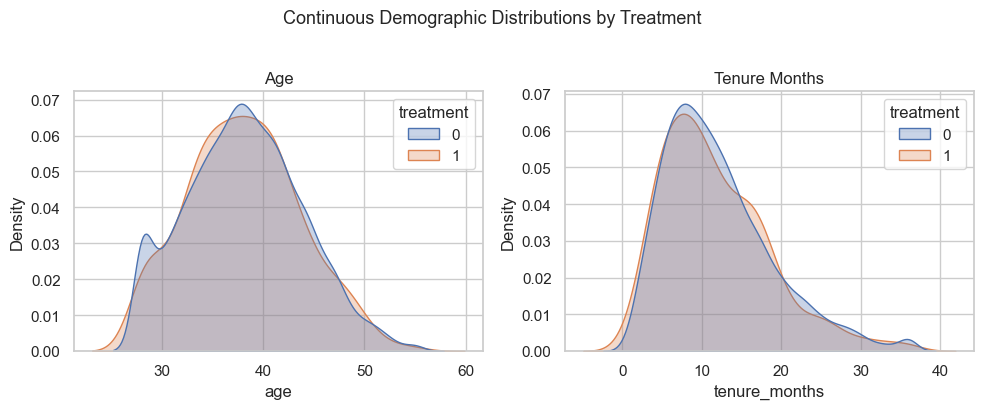

C:\Users\U1013877\AppData\Local\Temp\ipykernel_23320\1207658744.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


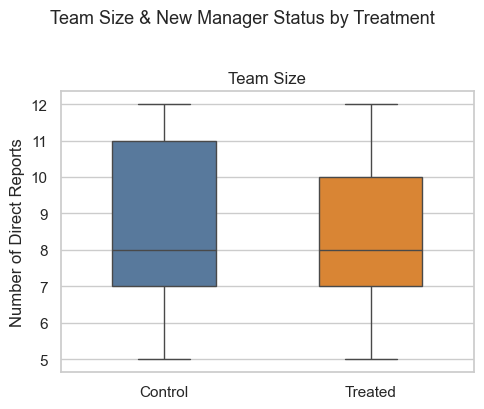

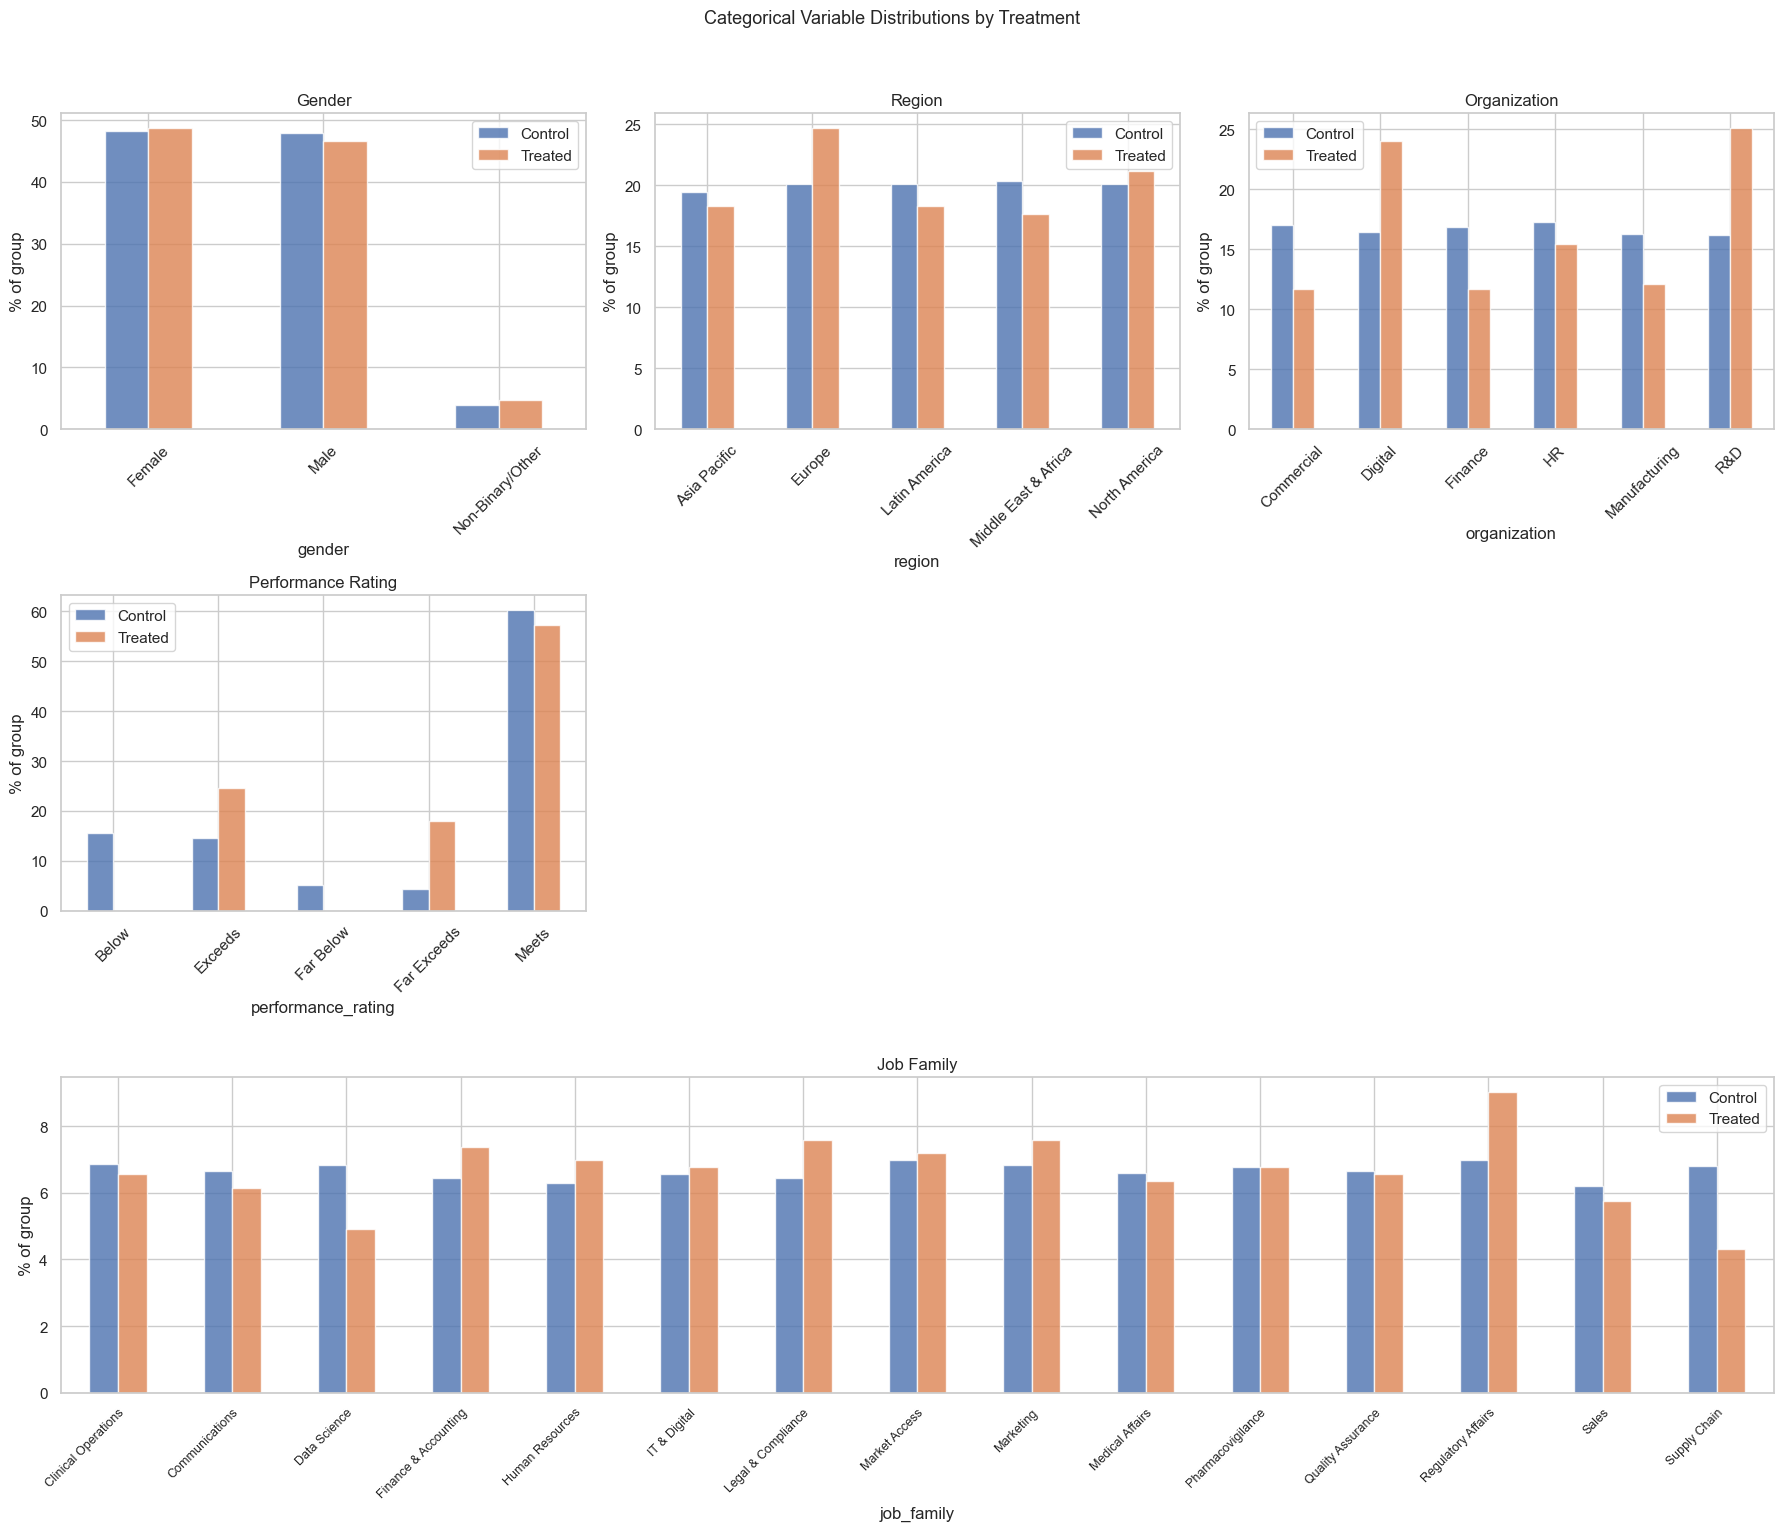

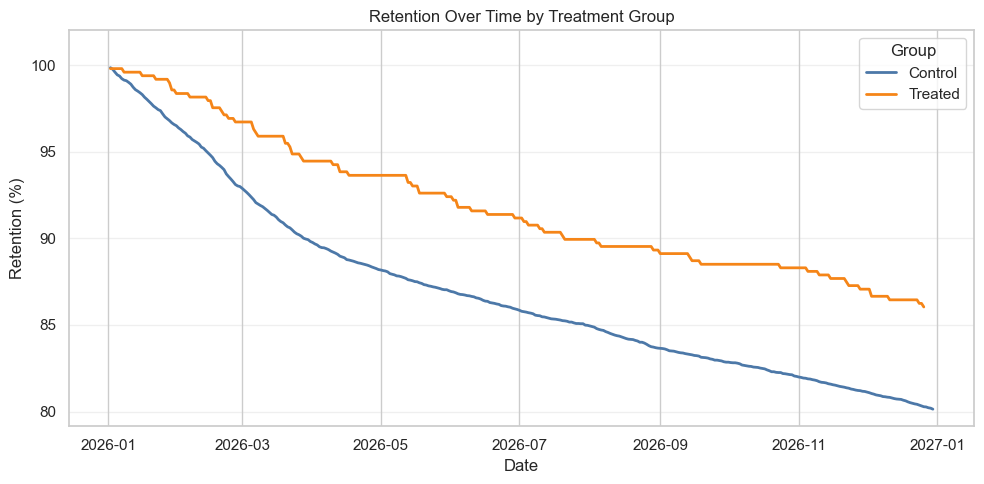

In [59]:
# =============================================================================
# DESCRIPTIVE EXPLORATION
# =============================================================================
# Compare outcomes for treated vs control, and explore potential confounders


def run_descriptive_comparison(data, treatment_col="treatment"):
    """Run demographic comparison between treated and control groups."""
    continuous_outcomes = [
        c for c in ["manager_efficacy_index", "workload_index_mgr", "turnover_intention_index_mgr"]
        if c in data.columns
    ]
    binary_outcomes = [
        c for c in ["retention_3month", "retention_6month", "retention_9month", "retention_12month"]
        if c in data.columns
    ]
    baseline_cols = [
        c for c in ["baseline_manager_efficacy", "baseline_workload",
                    "baseline_turnover_intention", "baseline_manager_support"]
        if c in data.columns
    ]

    demo_continuous = [c for c in ["age", "tenure_months"] if c in data.columns]
    demo_num = baseline_cols + demo_continuous + [c for c in ["num_direct_reports", "tot_span_of_control"] if c in data.columns]
    demo_cat = [
        c for c in ["gender", "region", "organization", "job_family", "performance_rating"]
        if c in data.columns
    ]

    print("=" * 60)
    print("BASELINE DEMOGRAPHIC & SURVEY COMPARISON: Treated vs Control")
    print("=" * 60)

    if demo_num:
        demo_means = data.groupby(treatment_col)[demo_num].mean().T
        demo_means.columns = ["Control", "Treated"]
        demo_means["Diff (T - C)"] = demo_means["Treated"] - demo_means["Control"]

        # Statistical tests for continuous/numeric variables
        p_values = []
        for col in demo_num:
            ctrl_vals = data.loc[data[treatment_col] == 0, col].dropna()
            treat_vals = data.loc[data[treatment_col] == 1, col].dropna()
            # Use Welch's t-test (does not assume equal variances)
            _, p = stats.ttest_ind(ctrl_vals, treat_vals, equal_var=False)
            p_values.append(p)
        demo_means["p-value"] = p_values
        demo_means["Sig. at 95%"] = demo_means["p-value"].apply(
            lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        )
        display(demo_means.round(3))

    if demo_cat:
        print("\n" + "-" * 60)
        for col in demo_cat:
            ct = pd.crosstab(data[col], data[treatment_col])
            ct.columns = ["Control", "Treated"]

            ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100
            ct_pct.columns = ["Control %", "Treated %"]
            ct_pct["Diff (pp)"] = ct_pct["Treated %"] - ct_pct["Control %"]

            # Chi-squared test of independence
            chi2, p_val, dof, _ = stats.chi2_contingency(ct.values)
            sig_label = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "not significantly"))
            print(f"\n{col}  —  χ² test to determine whether distributions differ among T & C = {chi2:.2f}, df = {dof}, p = {p_val:.4f} {sig_label}")
            display(ct_pct.round(1))

    n_cont = len(demo_continuous)
    if n_cont:
        fig, axes = plt.subplots(1, n_cont, figsize=(5 * n_cont, 4))
        if n_cont == 1:
            axes = [axes]
        for ax, col in zip(axes, demo_continuous):
            sns.kdeplot(
                data=data,
                x=col,
                hue=treatment_col,
                common_norm=False,
                fill=True,
                alpha=0.3,
                ax=ax,
            )
            ax.set_title(col.replace("_", " ").title())
        plt.suptitle("Continuous Demographic Distributions by Treatment", y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()

    special_plots = []
    if "num_direct_reports" in data.columns:
        special_plots.append("num_direct_reports")


    if special_plots:
        fig, axes = plt.subplots(1, len(special_plots), figsize=(5 * len(special_plots), 4))
        if len(special_plots) == 1:
            axes = [axes]
        plot_df_special = data.copy()
        plot_df_special["treatment_label"] = plot_df_special[treatment_col].map({0: "Control", 1: "Treated"})
        for ax, col in zip(axes, special_plots):
            if col == "num_direct_reports":
                sns.boxplot(
                    data=plot_df_special,
                    x="treatment_label",
                    y=col,
                    ax=ax,
                    order=["Control", "Treated"],
                    palette={"Control": "#4C78A8", "Treated": "#F58518"},
                    width=0.5,
                )
                ax.set_xlabel("")
                ax.set_ylabel("Number of Direct Reports")
                ax.set_title("Team Size")
            elif col == "is_new_manager":
                pct = (
                    data.groupby(treatment_col)[col]
                    .mean()
                    .reset_index()
                    .replace({treatment_col: {0: "Control", 1: "Treated"}})
                )
                sns.barplot(
                    data=pct,
                    x=treatment_col,
                    y=col,
                    ax=ax,
                    palette=["#4C78A8", "#F58518"],
                    width=0.5,
                )
                ax.set_ylabel("Proportion New Manager")
                ax.set_xlabel("")
                ax.set_title("Is New Manager")
                ax.set_ylim(0, 1)
        plt.suptitle("Team Size & New Manager Status by Treatment", y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()

    n_cat = len(demo_cat)
    if n_cat:
        other_cats = [col for col in demo_cat if col != "job_family"]
        n_other = len(other_cats)

        n_cols = 3
        n_rows = math.ceil(min(n_other, 6) / n_cols)

        fig = plt.figure(figsize=(18, 5 * (n_rows + 1)))
        gs = GridSpec(n_rows + 1, n_cols, height_ratios=[1] * n_rows + [1])

        for i, col in enumerate(other_cats[:n_rows * n_cols]):
            ax = fig.add_subplot(gs[i // n_cols, i % n_cols])
            ct_pct = pd.crosstab(data[col], data[treatment_col], normalize="columns") * 100
            ct_pct.columns = ["Control", "Treated"]
            ct_pct.plot(kind="bar", ax=ax, alpha=0.8)
            ax.set_title(col.replace("_", " ").title())
            ax.set_ylabel("% of group")
            ax.legend(title="")
            ax.tick_params(axis="x", rotation=45)

        if "job_family" in demo_cat:
            ax_job = fig.add_subplot(gs[n_rows, :])
            ct_pct = pd.crosstab(data["job_family"], data[treatment_col], normalize="columns") * 100
            ct_pct.columns = ["Control", "Treated"]
            ct_pct.plot(kind="bar", ax=ax_job, alpha=0.8)
            ax_job.set_title("Job Family")
            ax_job.set_ylabel("% of group")
            ax_job.legend(title="")
            ax_job.tick_params(axis="x", rotation=45, labelsize=9)
            ax_job.set_xticklabels(ax_job.get_xticklabels(), ha="right", rotation_mode="anchor")

        plt.suptitle("Categorical Variable Distributions by Treatment", y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()

    if "exit_date" in data.columns:
        exit_dates = pd.to_datetime(data["exit_date"], errors="coerce")
        retention_lines = []
        for trt, label, color in [(0, "Control", "#4C78A8"), (1, "Treated", "#F58518")]:
            mask = data[treatment_col] == trt
            n_group = mask.sum()
            dates = exit_dates[mask].dropna().sort_values()
            if n_group == 0 or dates.empty:
                continue
            daily_departures = dates.dt.normalize().value_counts().sort_index().cumsum()
            idx = pd.date_range(daily_departures.index.min(), daily_departures.index.max(), freq="D")
            daily_departures = daily_departures.reindex(idx, method="ffill").fillna(0)
            retention_pct = (1 - daily_departures / n_group) * 100
            retention_lines.append((label, color, retention_pct))

        if retention_lines:
            fig, ax = plt.subplots(figsize=(10, 5))
            for label, color, series in retention_lines:
                ax.plot(series.index, series.values, label=label, color=color, linewidth=2)
            ax.set_xlabel("Date")
            ax.set_ylabel("Retention (%)")
            ax.set_title("Retention Over Time by Treatment Group")
            ax.legend(title="Group")
            ax.set_ylim(None, 102)
            ax.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()


run_descriptive_comparison(data)

#### Positivity Violation: No Low Performers in the Treated Group

We observe that **zero managers rated "Far Below" or "Below" completed the training program.** This is a **positivity violation** — for this subgroup, the probability of treatment is exactly zero: $P(T=1 \mid \text{performance} \in \{\text{Far Below, Below}\}) = 0$.

This means we **cannot estimate the treatment effect for low performers** because there are no treated low performers to learn from. No statistical method can fix this — it is a fundamental data (program set-up) limitation.

**Our decision:** We exclude low performers from the analysis. This is a defensible response to positivity violations, but it has an important consequence: **our ATE now applies only to average-and-above performers.** If L&D scales this program to include low performers, our estimates are not informative about potential effects for this subgroup.

This is an **estimand-scoping decision**, not a data-cleaning step. It should be documented in any report and flagged as a limitation.

After exclusion: 7220 managers remain
treatment
0    6733
1     487
dtype: int64
BASELINE DEMOGRAPHIC & SURVEY COMPARISON: Treated vs Control


,Control,Treated,Diff (T - C),p-value,Sig. at 95%
baseline_manager_efficacy,2.490,2.357,-0.133,0.085,
baseline_workload,3.098,3.096,-0.002,0.967,
baseline_turnover_intention,2.721,2.761,0.040,0.375,
age,38.143,38.035,-0.108,0.681,
tenure_months,11.973,11.723,-0.250,0.433,
num_direct_reports,8.496,8.524,0.027,0.799,
tot_span_of_control,18.367,18.706,0.339,0.335,



------------------------------------------------------------

gender  —  χ² test to determine whether distributions differ among T & C = 1.18, df = 2, p = 0.5546 not significantly


,Control %,Treated %,Diff (pp)
gender,,,
Female,48.4,48.7,0.3
Male,47.8,46.6,-1.2
Non-Binary/Other,3.8,4.7,0.9



region  —  χ² test to determine whether distributions differ among T & C = 7.05, df = 4, p = 0.1333 not significantly


...

,Control %,Treated %,Diff (pp)
organization,,,
Commercial,17.3,11.7,-5.6
Digital,16.1,24.0,7.9
Finance,16.7,11.7,-5.0
HR,17.4,15.4,-2.0
Manufacturing,16.6,12.1,-4.5
R&D,15.9,25.1,9.2



job_family  —  χ² test to determine whether distributions differ among T & C = 11.80, df = 14, p = 0.6226 not significantly


,Control %,Treated %,Diff (pp)
job_family,,,
Clinical Operations,6.7,6.6,-0.2
Communications,6.4,6.2,-0.2
Data Science,6.7,4.9,-1.7
Finance & Accounting,6.5,7.4,0.9
Human Resources,6.4,7.0,0.6
IT & Digital,6.6,6.8,0.2
Legal & Compliance,6.5,7.6,1.1
Market Access,7.1,7.2,0.1
Marketing,6.8,7.6,0.8



performance_rating  —  χ² test to determine whether distributions differ among T & C = 145.80, df = 2, p = 0.0000 ***


,Control %,Treated %,Diff (pp)
performance_rating,,,
Exceeds,18.4,24.6,6.3
Far Exceeds,5.5,18.1,12.6
Meets,76.2,57.3,-18.9


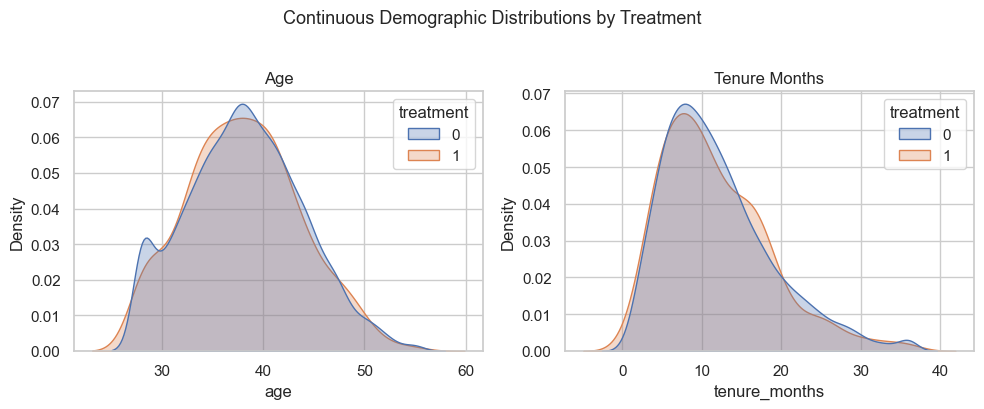

C:\Users\U1013877\AppData\Local\Temp\ipykernel_23320\1207658744.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


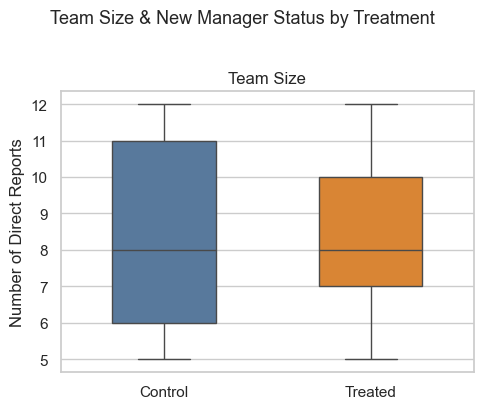

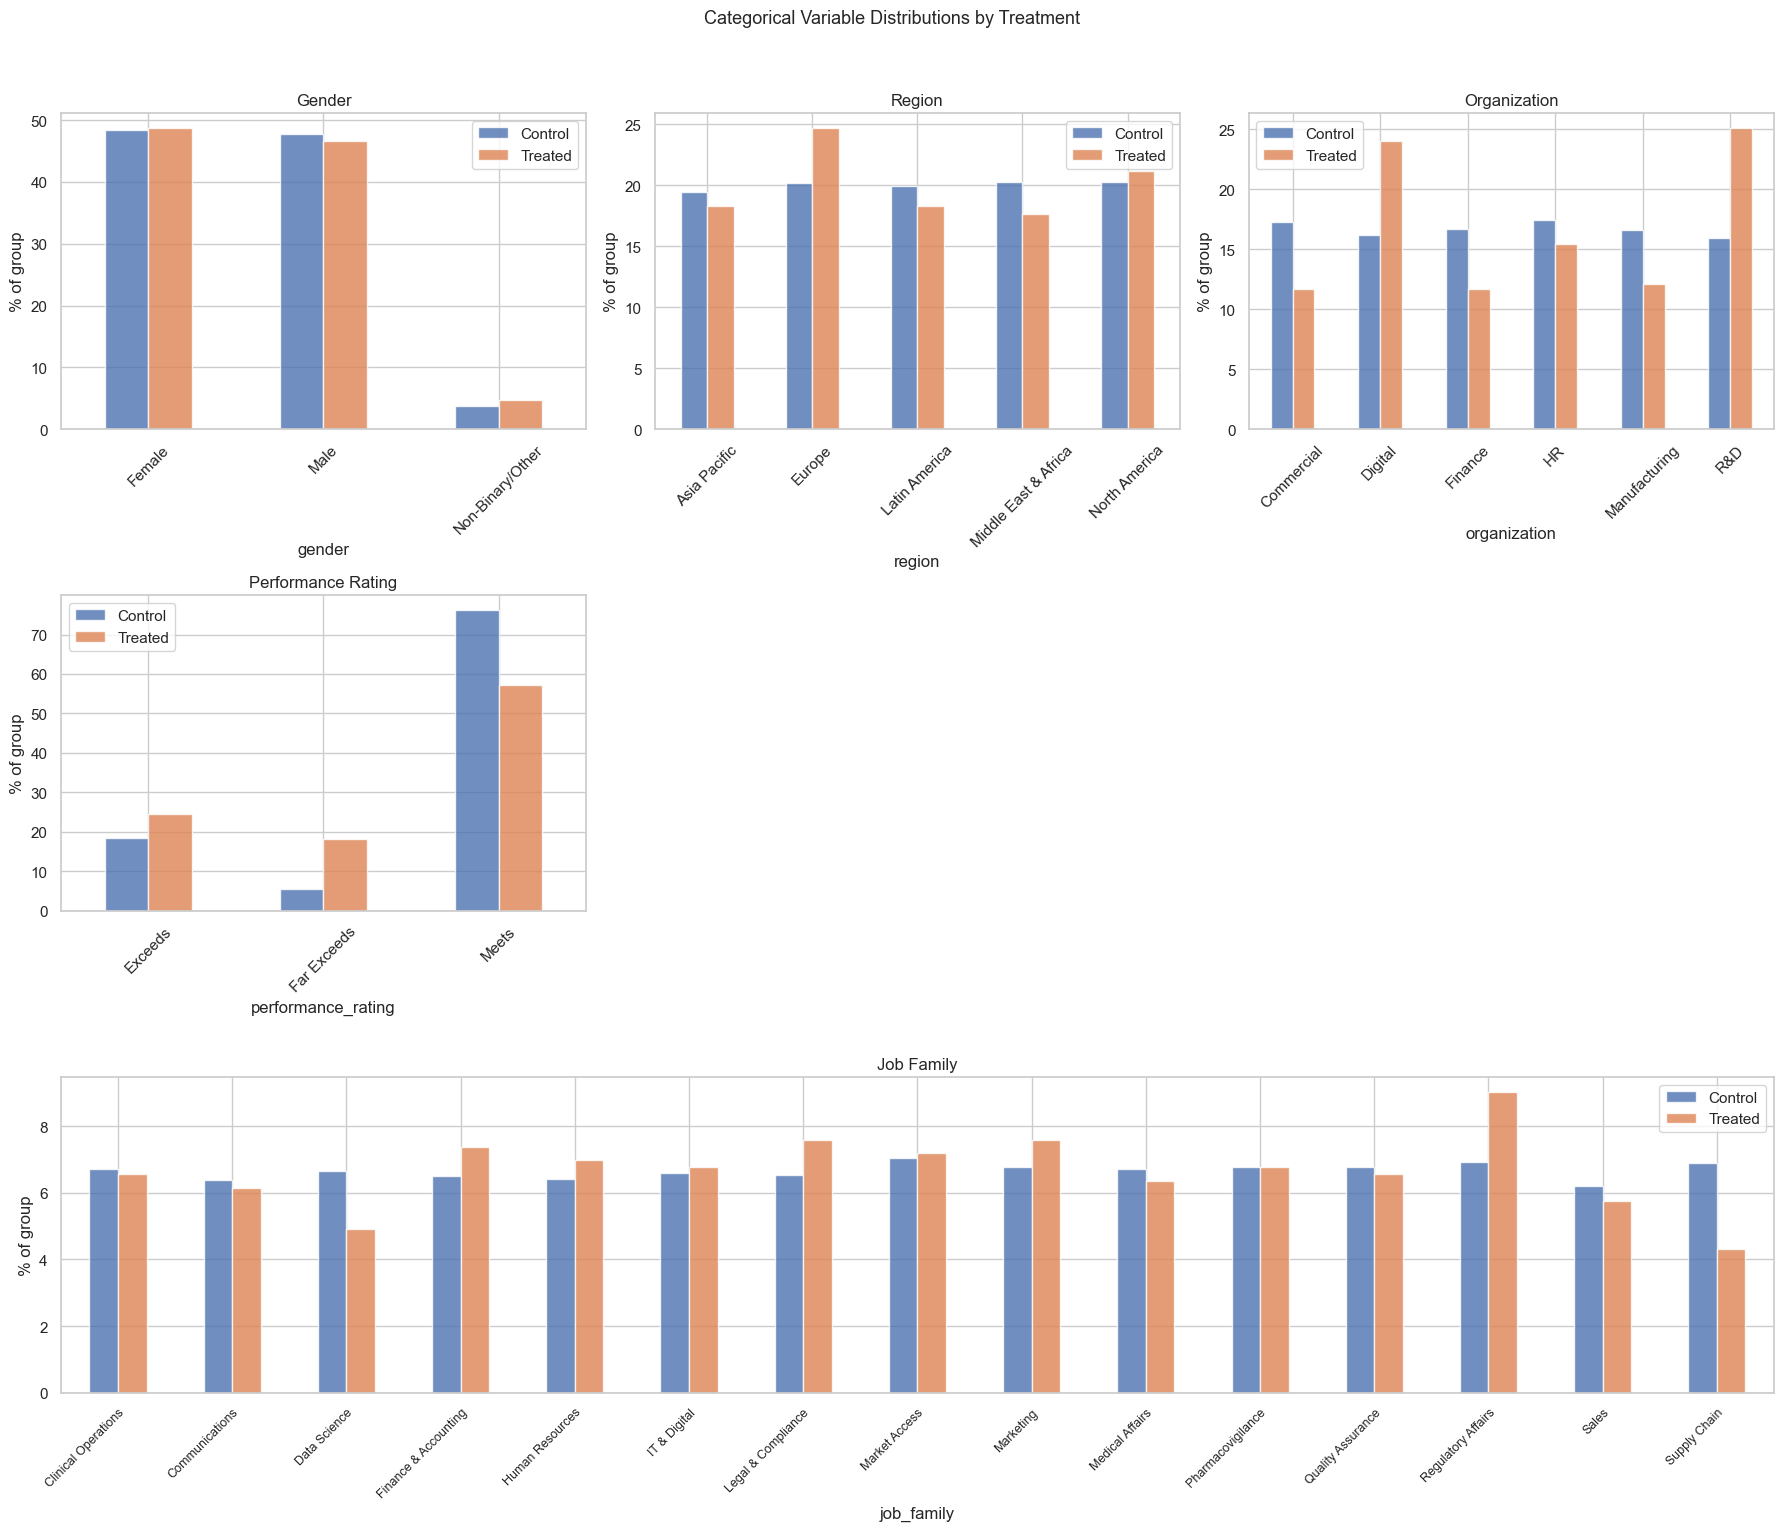

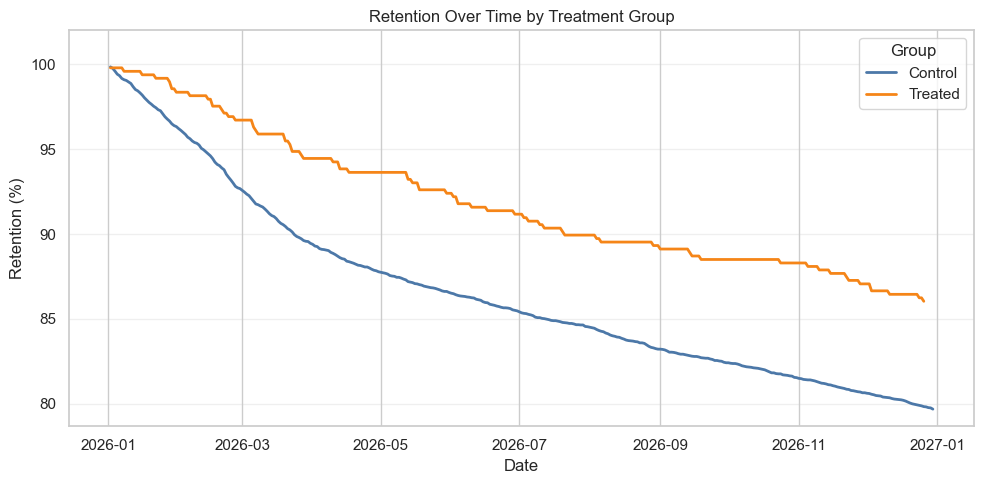

In [60]:
# Exclude low performers (positivity violation — see discussion above)
data = data[~data["performance_rating"].isin(["Far Below", "Below"])].copy().reset_index(drop=True)
print(f"After exclusion: {data.shape[0]} managers remain")
print(data.groupby("treatment").size())

# Re-run descriptives on restricted sample
run_descriptive_comparison(data)

---

## Checkpoint 2: Diagnostics & Causal Identification Strategy

<img src="./diagrams/checkpoint2.png" width = "400" alt="Alt text">

First, we will determine the appropriate estimand for measuring treatment effect.


**Let's compare our estimand options: Average Treatment Effect (ATE) and Average Treatment Effect on the Treated (ATT)**
| Consideration | ATE | ATT |
|---------------|-----|-----|
| **Target population** | Full population (treated + untreated) | Only those who received treatment |
| **Research question** | "What would happen if we rolled this out to everyone?" | "Did the program work for those who actually participated?" |
| **Overlap requirement** | Strict: every covariate profile needs both treated and control individuals | Relaxed: only need controls that resemble the treated |
| **Typical use case** | Policy decisions about universal rollout | Evaluating a voluntary or targeted program |
| **When treated group is small** | Problematic — requires extrapolating to dissimilar individuals | Natural fit — you're only generalizing to the treated |

**Now, let's revisit our context and research question.**

- Participation was **voluntary** — any manager who signed up could attend the January–March training
- **Promotion of the program varied across departments**: some units actively encouraged participation, others sent a single email announcement
- The L&D team's goal is to **train as many managers as possible** — they want to know if they should scale this program potentially to everyone.

**Our target estimand of interest: ATE (Average Treatment Effect)**

Since L&D wants to scale training to all managers, we want to estimate the **population-level effect** — what would happen if we assigned training to everyone vs. no one? This maps to the ATE, not the ATT (which only tells us about self-selected participants and what would have happened if they did not participate).

We will conduct diagnostics to determine if our data structure allows us estimating ATE. If not, we can still get useful insights from ATT. And, as a last resort, if the data set is not suitable for any causal inference, we would be limited to descriptive/exploratory analysis.

**Side note — Encouragement Design & Instrumental Variables.** In principle, the department-level variation in how actively the program was promoted resembles a natural encouragement design: departments that encouraged participation more strongly could serve as an instrument that shifts the probability of training uptake. An Instrumental Variable (IV) approach could then estimate a Local Average Treatment Effect (LATE) for compliers — managers whose participation was driven by the encouragement. However, the validity of this approach rests on the exclusion restriction: the instrument must affect outcomes only through participation. That assumption is questionable here — departments that actively promoted the training likely differ in other ways (e.g., stronger learning culture, more supportive leadership, additional development resources) that could independently influence manager outcomes. We will not pursue this path in the current exercise, but it is worth keeping in mind as a strategy for settings where a more credibly exogenous source of encouragement exists.

### Diagnostic Prep

In [61]:
###############################################
# DIAGNOSTIC AND ANALYSIS PREP
###############################################

# Treatment variable
treatment = 'treatment'

# Survey outcome variables (continuous, with baselines)
survey_outcomes = [
    'manager_efficacy_index',
    'workload_index_mgr',
    'turnover_intention_index_mgr',
]

# Baseline variables corresponding to each survey outcome
baseline_vars = {
    'manager_efficacy_index': 'baseline_manager_efficacy',
    'workload_index_mgr': 'baseline_workload',
    'turnover_intention_index_mgr': 'baseline_turnover_intention',
}

# Covariates (shared between survey and retention analyses)
categorical_vars = [
    'gender',
    'organization',
    'job_family',
    'performance_rating',
    'region'
]


continuous_vars = [
    'age',
    'tenure_months',
    'num_direct_reports',
    'tot_span_of_control'
]

print(f"Survey outcomes:    {survey_outcomes}")
print(f"Covariates:         {len(categorical_vars)} categorical, {len(continuous_vars)} continuous")

Survey outcomes:    ['manager_efficacy_index', 'workload_index_mgr', 'turnover_intention_index_mgr']
Covariates:         5 categorical, 4 continuous


In [62]:
# Instantiate CausalDiagnostics and view help
cd = CausalDiagnostics()
cd.help()


        ╔══════════════════════════════════════════════════════════════════════════════╗
        ║  CausalDiagnostics — Unified Causal Inference Diagnostic Toolkit             ║
        ╚══════════════════════════════════════════════════════════════════════════════╝

        Usage:
            from supp_functions.causal_diagnostics import CausalDiagnostics
            cd = CausalDiagnostics()

        ────────────────────────────────────────────────────────────────────────────────
        GROUP A: PRE-MODELING DIAGNOSTICS
        ────────────────────────────────────────────────────────────────────────────────

        1. check_high_intercorrelations(df, numerical_threshold=0.7,
                                        categorical_threshold=0.7, verbose=False,
                                        exclude_vars=None)
        Detect highly correlated variable pairs using:
            • Pearson correlation     (numerical–numerical)
            • Cramér's V              (categorical–categ

### Initial Diagnostics: Multicollinearity/VIF

When you include multiple covariates in a regression model (like the propensity score model), some of them may be highly correlated with each other. Why is it important: Multicollinearity doesn't bias your estimates, but it inflates the standard errors, making it harder to detect real effects and producing unstable coefficient estimates (especially when you work with smaller sample sizes - as usually the case in People Analytics). 

| Function | Purpose |
|----------|---------|
| `check_high_intercorrelations` | Flags pairs above threshold (default 0.7) using Pearson, Cramér's V, or η |
| `check_vif` | Assesses multicollinearity via VIF (continuous) and adjusted GVIF (categorical). VIF shows "How well can this variable be predicted by all the other variables in the model?" |

In [63]:
# Variables to exclude from pre-modeling checks (outcomes, IDs, treatment, extra retention columns)
retention_cols = [c for c in data.columns if c.startswith('retention_')]
exclude_from_diagnostics = (
    ['id', 'team_id', 'treatment', 'exit_date']
    + survey_outcomes
    + retention_cols
    + [v for v in baseline_vars.values() if v is not None]
)

# --- Check 1: Intercorrelations ---
print("=" * 60)
print("CHECK 1: INTERCORRELATIONS")
print("=" * 60)
intercorr = cd.check_high_intercorrelations(
    data,
    numerical_threshold=0.7,
    categorical_threshold=0.7,
    verbose=True,
    exclude_vars=exclude_from_diagnostics,
)
if not intercorr['all_high_correlation_pairs']:
    print("✅ No highly correlated pairs found.")
else:
    print(f"⚠️ Found {len(intercorr['all_high_correlation_pairs'])} highly correlated pair(s).")

# --- Check 2: Variance Inflation Factor (VIF) ---
print("\n" + "=" * 60)
print("CHECK 2: VARIANCE INFLATION FACTOR (VIF)")
print("=" * 60)
controls_for_vif = categorical_vars + continuous_vars
vif_results = cd.check_vif(
    data,
    controls=controls_for_vif,
    treatment='treatment',
)
display(vif_results)

CHECK 1: INTERCORRELATIONS
✅ No highly correlated pairs found.

CHECK 2: VARIANCE INFLATION FACTOR (VIF)


,Variable,Type,VIF / GVIF,Adjusted (GVIF^1/2df),Shared Variance,Severity
0,tot_span_of_control,Continuous,1.1150,1.1150,<25% of variance is shared,✅ None
1,num_direct_reports,Continuous,1.1150,1.1150,<25% of variance is shared,✅ None
2,treatment,Continuous,1.0327,1.0327,<25% of variance is shared,✅ None
3,performance_rating,Categorical (2 dummies),1.0299,1.0074,<25% of variance is shared,✅ None
4,age,Continuous,1.0054,1.0054,<25% of variance is shared,✅ None
5,tenure_months,Continuous,1.0053,1.0053,<25% of variance is shared,✅ None
6,organization,Categorical (5 dummies),1.0256,1.0025,<25% of variance is shared,✅ None
7,gender,Categorical (2 dummies),1.0071,1.0018,<25% of variance is shared,✅ None
8,region,Categorical (4 dummies),1.0146,1.0018,<25% of variance is shared,✅ None
9,job_family,Categorical (14 dummies),1.0341,1.0012,<25% of variance is shared,✅ None


### Overlap Diagnostics

<img src="./diagrams/DiagnosticFlow.png" width = "1000" alt="Alt text">

In [64]:
# ===========================================================================================================================================
# PRE-MODELING DIAGNOSTICS : IS CAUSAL COMPARISON CREDIBLE, AND WHAT ESTIMAND IS DEFENSIBLE?
# 1. Overlap Diagnostics: Do the treatment and control groups have sufficient overlap in covariate distributions?
# 2. Based on the diagnostics, determine if the data supports a credible causal comparison.
# ===========================================================================================================================================
# Note: The propensity score model depends on covariates + treatment (not the outcomes). 
# Below, we run it here once for the 3 survey outcomes, because, depending on the outcome, we are using a different baseline variable as a covariate (that needs to be checked for balance). 
# The approach will be identical for the retention analysis.

overlap_results = cd.run_overlap_diagnostics(
    data=data,
    treatment_var=treatment,
    outcome_vars=survey_outcomes,
    baseline_vars=baseline_vars,
    categorical_vars=categorical_vars,
    continuous_vars=continuous_vars
)


STEP 2: OVERLAP / COMMON SUPPORT DIAGNOSTICS

    This step determines WHICH ESTIMAND (ATT vs ATE) is credible in your data.

    KEY CONCEPTS:
    - ATT (Average Treatment Effect on the Treated): Effect for those who got treatment
    → Requires: Good overlap for TREATED units (each treated has comparable controls)

    - ATE (Average Treatment Effect): Effect if we treated everyone
    → Requires: Good overlap BOTH directions (treated exist across control range too)

    With imbalanced samples, ATT is typically the credible estimand because
    many controls sit in regions where no treated units exist.

    We'll check overlap for each outcome (since adjustment sets include different baselines).
        
DETAILED DIAGNOSTICS
Checks 1A–1C (continuous, binary, categorical SMDs) are identical
across outcomes. Only baseline check (1D) and propensity-score model
(Check 2) vary by outcome due to outcome-specific baseline variables.
Showing full detail for first outcome: manager_efficacy_

,Outcome,AUC,Treated Overlap %,Control Overlap %,Max |SMD| (Source),Baseline Balance,Imbalanced Vars,Estimand,Rationale
0,manager_efficacy_index,0.645,89.9,91.0,0.401 (performance_rating),✓ Good (0.082),performance_rating (0.40); organization (0.23)...,ATE,Strong bidirectional overlap; ATE fully defens...
1,workload_index_mgr,0.640,88.1,91.9,0.401 (performance_rating),✓ Good (0.002),performance_rating (0.40); organization (0.23)...,ATE,Strong bidirectional overlap; ATE fully defens...
2,turnover_intention_index_mgr,0.637,90.6,92.4,0.401 (performance_rating),✓ Good (0.041),performance_rating (0.40); organization (0.23)...,ATE,Strong bidirectional overlap; ATE fully defens...



INTERPRETATION GUIDE: WHAT THIS MEANS FOR YOUR ANALYSIS

    ╔══════════════════════════════════════════════════════════════════════════════╗
    ║  WHAT IS COVARIATE OVERLAP AND WHY DOES IT MATTER?                           ║
    ╠══════════════════════════════════════════════════════════════════════════════╣
    ║                                                                              ║
    ║  Causal inference requires COMPARABLE treatment and control groups.          ║
    ║  "Comparable" means: for each treated person, there exist control people     ║
    ║  with similar characteristics (covariates) who can serve as counterfactuals. ║
    ║                                                                              ║
    ║  If groups occupy DIFFERENT covariate spaces, we cannot observe what would   ║
    ║  have happened to treated people without treatment — we must EXTRAPOLATE.    ║
    ║                                                                              ║
    ║  

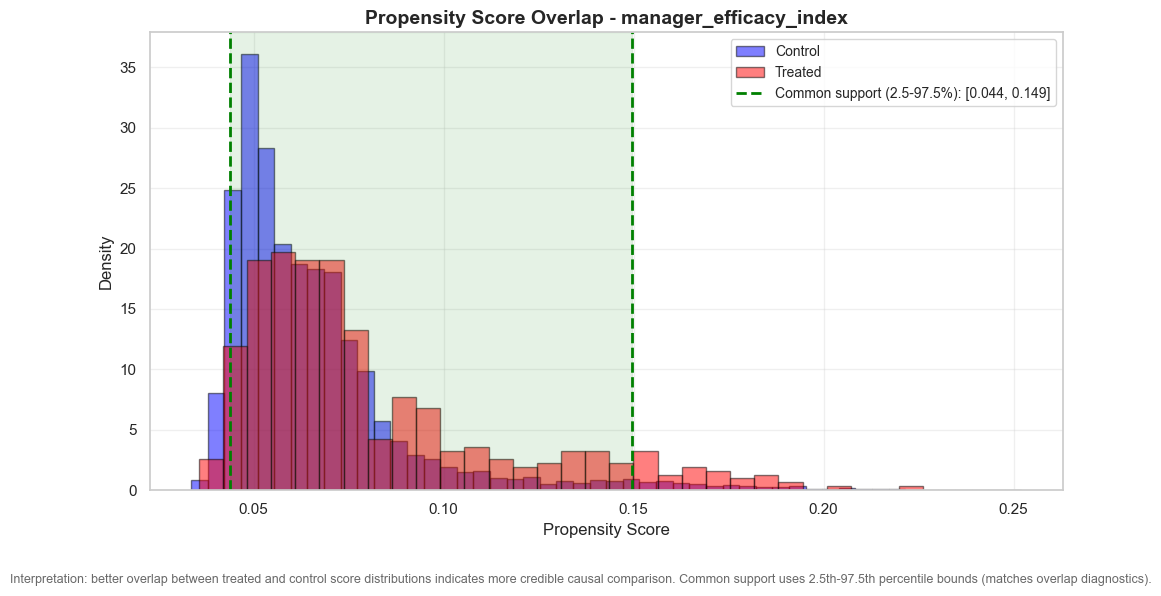

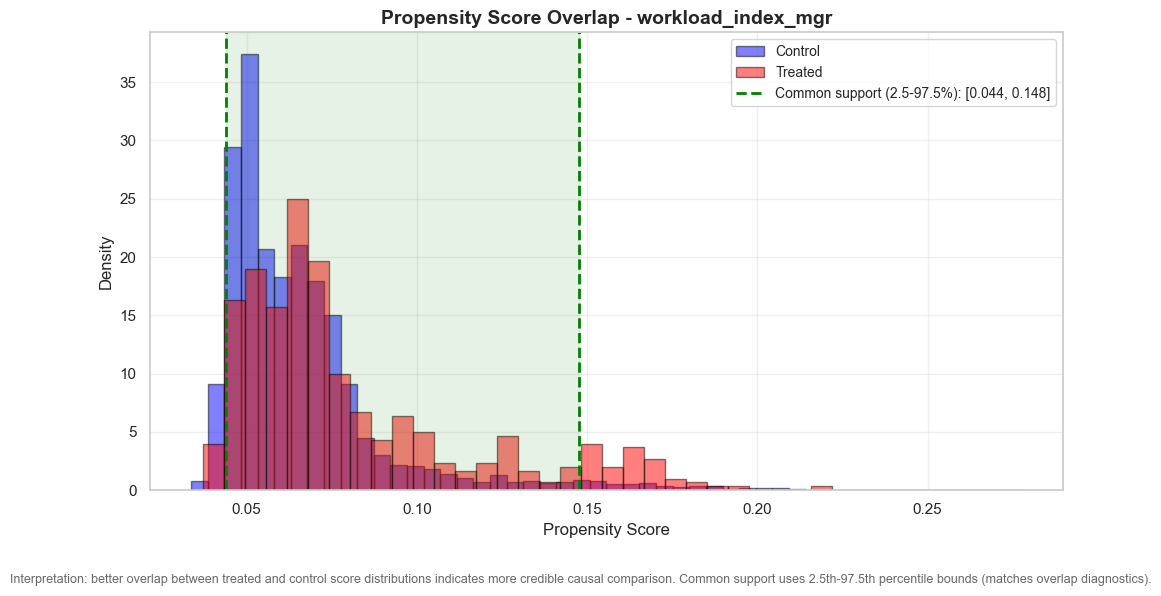

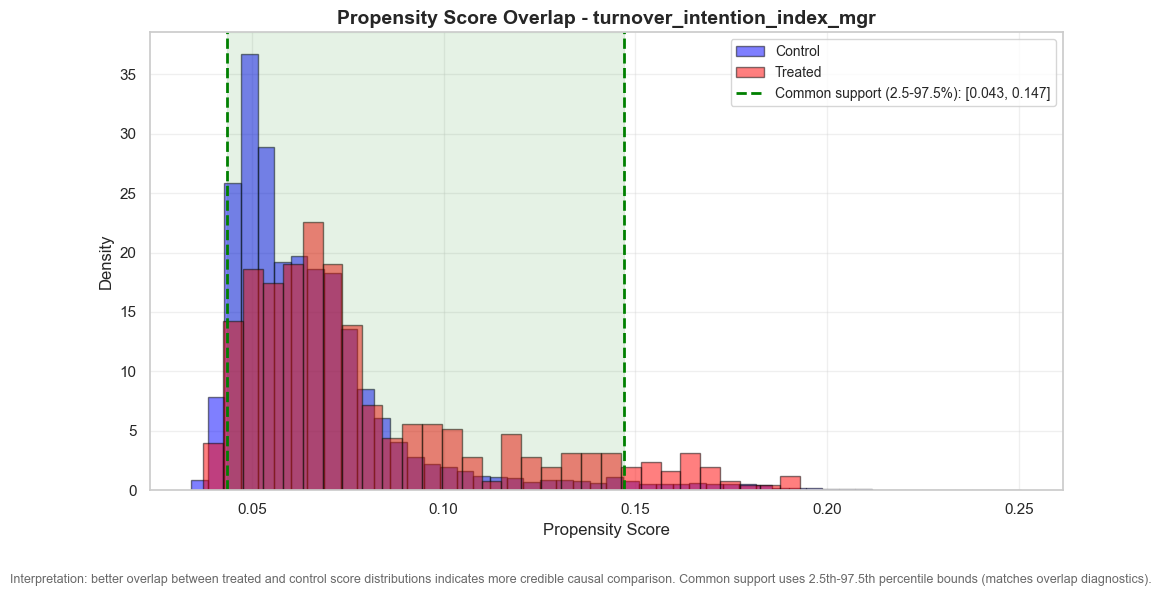

In [65]:
# =============================================================================
# Visualize propensity score overlap per survey outcome
# =============================================================================
for outcome_var in survey_outcomes:
    result = overlap_results.get(outcome_var)
    if result is None:
        continue

    ps = result.get('propensity_scores')
    if ps is not None:
        cd.plot_propensity_overlap(
            data=data,
            treatment_var=treatment,
            propensity_scores=ps,
            outcome_var=outcome_var,
        )

In [66]:
# =============================================================================
# Save overlap diagnostics summary
# =============================================================================
cd.save_overlap_diagnostics_summary(
    overlap_results,
    save_path=str(base_dir / "results/overlap_diagnostics_summary.txt"),
)


✓ Diagnostics summary saved to: c:\Users\U1013877\OneDrive - Sanofi\Documents\GitHub\2026-siop-causal-inference-master-tutorial\results\overlap_diagnostics_summary.txt


## Checkpoint 3: Modeling

<img src="./diagrams/checkpoint3.png" width = "600" alt="Alt text">

---

### Survey Outcomes - IPTW + GEE: Estimating Average Treatment Effect

Use this approach when treatment is not purely randomized, propensity scores are well-distributed (good overlap), and weighted standardized mean differences (SMDs) are acceptable.

This approach estimates the **Average Treatment Effect (ATE)** using:

- **Stabilized and trimmed inverse probability of treatment weights (IPTW)** to balance treatment groups on observed confounders
- **Generalized Estimating Equations (GEE) with clustering** (exchangeable working correlation structure to account for within-cluster correlation: employees nested within manager teams may experience correlated outcomes due to shared team dynamics or local shocks)
- **Robust sandwich standard errors** from GEE to ensure valid inference even if the working correlation structure is misspecified
- Covariate adjustment in the outcome model for **doubly robust estimation**: additional protection from model misspecification (valid inference if either the propensity score model or the outcome model is correctly specified)

> **Note on estimand:** GEE itself is agnostic to the estimand — it simply fits a weighted regression with cluster-robust standard errors. Whether you estimate the **ATE** or the **ATT** is determined entirely by how the weights are constructed. This implementation uses **ATE weights**, which reweigh both treated and control groups to represent the full population.

---

Let:

- $Y_i$ = outcome for individual $i$
- $Treatment_i$ = 1 if individual $i$ participated, 0 otherwise
- $X_i$ = pre-treatment individual-level covariates
- $Team_i$ = the direct manager's team that individual $i$ belongs to (used for clustering). Note, as a rule of thumb, it is recommended to have at least 30-50 clusters. For fewer clusters, standard errors might be too high (blurring the true results). In that case, boot-strapping standard errors can be used as an alternative. 

The weighted GEE model is:

$$
g\big(E[Y_i]\big) =
\beta_0 + \beta_1 \cdot Treatment_i + \beta_2 \cdot X_i
$$

Where:

- $g(\cdot)$ is the link function (identity for continuous outcomes, logit for binary outcomes)
- Weights = **stabilized and trimmed ATE inverse probability weights**
- Propensity scores are estimated at the **individual level** — one score per person, reflecting the probability that an individual received treatment given their observed covariates: $\hat{e}_i = P(Treatment_i = 1 \mid X_i)$
- **ATE weights** are then constructed as:
  - Treated individuals: $w_i = 1 \;/\; \hat{e}_i$
  - Control individuals: $w_i = 1 \;/\; (1 - \hat{e}_i)$
  - This reweights **both** groups to represent the full population — upweighting individuals who were unlikely to receive the treatment they actually received
  - For comparison, **ATT weights** would leave treated individuals unweighted ($w_i = 1$) and reweight controls as $w_i = \hat{e}_i \;/\; (1 - \hat{e}_i)$ to match the treated group's covariate distribution. The choice of ATE vs. ATT is entirely determined by the weight formula, not by GEE.
- Weights are **stabilized** by multiplying by the marginal treatment probability:
  - Treated: $w_i^{stab} = \bar{p} \;/\; \hat{e}_i$
  - Control: $w_i^{stab} = (1 - \bar{p}) \;/\; (1 - \hat{e}_i)$
  - where $\bar{p}$ is the sample-average treatment probability. Stabilization reduces the range of weight values while preserving balance.
- Weights are **trimmed** by capping values above a specified quantile (e.g., 99th percentile). This reduces the influence of individuals with extreme propensity scores — those who were very unlikely to receive the treatment they actually received — which can otherwise destabilize estimates. Trimming introduces a small bias but substantially reduces variance.
- Clustering is specified at the **team level** (by direct manager ID) — individuals who share the same direct manager are grouped together. GEE sandwich standard errors account for the fact that teammates may have correlated outcomes due to shared work environment, leadership, and team dynamics.
- Note: GEE sandwich standard errors account for within-team correlation but do **not** propagate uncertainty from the first-stage propensity score estimation. For stricter inference, consider a non-parametric bootstrap that re-estimates both stages in each replicate.

---

#### Continuous Outcome (Identity Link)

$$
E[Y_i] =
\beta_0 + \beta_1 \cdot Treatment_i + \beta_2 \cdot X_i
$$

- $\beta_1$ = **ATE**: the weighted average difference in outcomes between treated and control individuals, after reweighting to balance observed confounders
- Interpretation: on average across the population, treatment shifts the outcome by $\beta_1$ units

---

#### Binary Outcome (Logit Link)


$$\log\left(\frac{P(Y_i=1)}{1-P(Y_i=1)}\right) = \beta_0 + \beta_1 \cdot Treatment_i + \beta_2 \cdot X_i$$

- $e^{\beta_1}$ = **population-averaged marginal odds ratio**: the odds of the outcome occurring for treated individuals relative to control individuals, averaged across the population
- Note: because GEE estimates population-averaged (marginal) effects rather than subject-specific effects, $e^{\beta_1}$ reflects the average odds ratio across all individuals, not the odds ratio for any particular person

---

#### Protection from Model Misspecification

Including covariates in both the propensity score model (via weights) and the outcome model (via regression adjustment) provides additional protection: the treatment effect estimate is consistent if **at least one** of the following holds:

- The propensity score model $P(Treatment_i = 1 \mid X_i)$ is correctly specified, **or**
- The outcome model (including $X_i$) is correctly specified

This property, sometimes called double robustness under linearity, gives you two chances instead of one. However, both models here use the same covariates with main-effects-only functional forms — so misspecification of the functional form (e.g., missing interaction terms) could affect both simultaneously. This is a safeguard, not a guarantee.

Two additional assumptions are always required regardless of model correctness:

- **Positivity (overlap):** Every individual must have a non-zero probability of receiving either treatment or control given their covariates — i.e., $0 < P(Treatment_i = 1 \mid X_i) < 1$ for all $i$. Violations (propensity scores near 0 or 1) produce extreme weights and unstable estimates.
- **Correct temporal ordering:** All covariates $X_i$ must be measured **prior to** treatment assignment to qualify as true pre-treatment confounders. Including post-treatment variables as covariates can introduce bias.

---

#### Summary: Model Design Choices

| Design Choice | Problem It Solves | Example | What It Does |
|---------------|-------------------|---------|--------------|
| **IPTW (Inverse Probability of Treatment Weighting)** | Treatment assignment is non-random; treated and control groups differ on observed confounders | Individuals who volunteered for training differ systematically from those who didn't (e.g., higher baseline performance, more tenure) | Reweights observations so treated and control groups have balanced covariate distributions, mimicking randomization. Upweights individuals who were unlikely to receive the treatment they got; downweights those who were likely to receive it. |
| **ATE Weights** | You want to estimate the effect of treatment across the **full population**, not just those who were treated | Deciding whether to mandate a program for all individuals | Reweights **both** treated and control groups to represent the full population. Treated: $w_i = 1/\hat{e}_i$, Control: $w_i = 1/(1-\hat{e}_i)$. Contrast with ATT weights, which leave treated unweighted and reweight controls to match the treated group. |
| **Stabilized Weights** | Extreme weights from rare propensity scores cause high variance and unstable estimates | An individual with PS = 0.02 gets weight = 1/0.02 = 50, dominating the analysis | Multiplies weights by the marginal treatment probability $\bar{p}$, reducing the range of weight values while preserving balance. Stabilized weights have mean ≈ 1 instead of highly variable. |
| **Weight Trimming** | A few individuals with extreme propensity scores (near 0 or 1) produce outlier weights that destabilize estimates | One person with PS = 0.001 gets weight = 1000, overwhelming all other observations | Caps weights at a specified quantile (e.g., 99th percentile). Introduces small bias but substantially reduces variance. Trades off some precision for stability. Note: It's best practice to check weight distributions and effective sample size to validate the trim threshold — defaults may not be optimal for your sample size and overlap patterns. |
| **GEE Clustering** | Observations within groups (teams) are not independent; teammates share common shocks and environments | Individuals under the same manager have correlated outcomes due to shared leadership style, team culture, workload | Models within-cluster correlation structure and adjusts coefficient estimation accordingly. Produces population-averaged (marginal) effects rather than cluster-specific effects. Prevents underestimation of standard errors. |
| **Sandwich (Robust) Standard Errors** | Model assumptions about variance structure may be wrong (heteroskedasticity, misspecified correlation) | You assumed exchangeable correlation within teams, but the true correlation structure is more complex | Uses observed residuals to empirically estimate the true variance, producing standard errors that are valid even if variance assumptions are violated. Makes GEE robust to misspecification of the working correlation structure. Note: SEs do not account for first-stage propensity score estimation uncertainty; consider cluster bootstrap for fully valid inference. |
| **Covariate Adjustment in Both Stages** | Uncertainty about whether propensity score model or outcome model is correctly specified | You're not sure if you've included all relevant confounders, or if the functional form of relationships is correct | Includes covariates in both the propensity score model (via weights) and the outcome model (via regression adjustment). Under linearity, the ATE estimate is consistent if **either** model is correctly specified. Both models use the same covariates with main-effects-only forms, so misspecification of functional form could affect both. |
| **Propensity Score Clipping** | Division by propensity scores near 0 or 1 produces infinite or undefined weights | Propensity score = 0.0000001 → weight = 10,000,000 | Clips propensity scores to a safe range (e.g., [0.000001, 0.999999]) before calculating weights. Prevents numerical overflow and extreme weight values. |
| **Auto-Detection of Outcome Family** | Binary and continuous outcomes require different link functions and distributional assumptions | Retention (0/1) needs logit link; engagement score (1-5) needs identity link | Inspects unique values of the outcome variable. If only {0, 1}, uses Binomial family with logit link. Otherwise, uses Gaussian family with identity link. Ensures appropriate model specification. |
| **Multiple Testing Correction (FDR)** | Testing multiple outcomes inflates Type I error rate (false positives) | Testing 7 outcomes at α=0.05 gives ~30% chance of at least one false positive under the null | Applies Benjamini-Hochberg FDR correction across all p-values within an outcome family. Controls the expected proportion of false discoveries among rejected hypotheses. Applied **across outcomes**. |

#### Why GEE Instead of OLS with Cluster-Robust Standard Errors?

For our continuous survey outcomes with one observation per manager and team-level clustering, **GEE with an exchangeable working correlation and sandwich standard errors produces results that are very similar to weighted least squares (WLS) with cluster-robust covariance.** Either approach would be defensible here. We use GEE for three reasons:

**1. It generalizes naturally to non-continuous outcomes.** GEE handles Gaussian, Binomial, and other families through the same interface. If your outcomes include binary flags alongside continuous scales — common in applied program evaluation — GEE lets you use a single modeling framework rather than switching between WLS and logistic regression.

**2. It models within-cluster correlation explicitly.** GEE specifies a working correlation structure (here, exchangeable — assuming constant pairwise correlation among teammates). When this structure is approximately correct, GEE can be more efficient than OLS, producing tighter confidence intervals. The efficiency gain is typically small for cross-sectional data with moderate cluster sizes, but it becomes substantial in longitudinal settings with repeated measures on the same individual — a common extension of this type of analysis.

**3. It is the conventional choice in the causal inference literature.** The Robins-Hernán tradition of marginal structural models pairs IPTW with GEE as the standard estimation approach. Using GEE aligns this workshop with the broader methodological literature, making it easier for participants to connect what they learn here to published research and textbooks.

**Important caveat:** With sandwich (robust) standard errors, GEE coefficient estimates are consistent regardless of whether the working correlation is correctly specified. The working correlation affects efficiency but not validity. This means GEE's advantage over WLS with cluster-robust SEs is an efficiency argument, not a consistency argument — and the efficiency gain is modest when you have a single cross-sectional observation per person (as we do here) rather than repeated measures.

> **If you are adapting this analysis for your own work** and your outcomes are all continuous with simple team-level clustering, `statsmodels.formula.api.wls(...).fit(cov_type="cluster", cov_kwds={"groups": cluster_col})` is a simpler alternative that produces nearly identical results.

#### Run the GEE Model


ANALYZING OUTCOME: manager_efficacy_index

📊 Analyzing outcome: manager_efficacy_index
⚠️  REMINDER: This returns raw p-values. For multiple outcomes, use build_summary_table() for FDR correction.


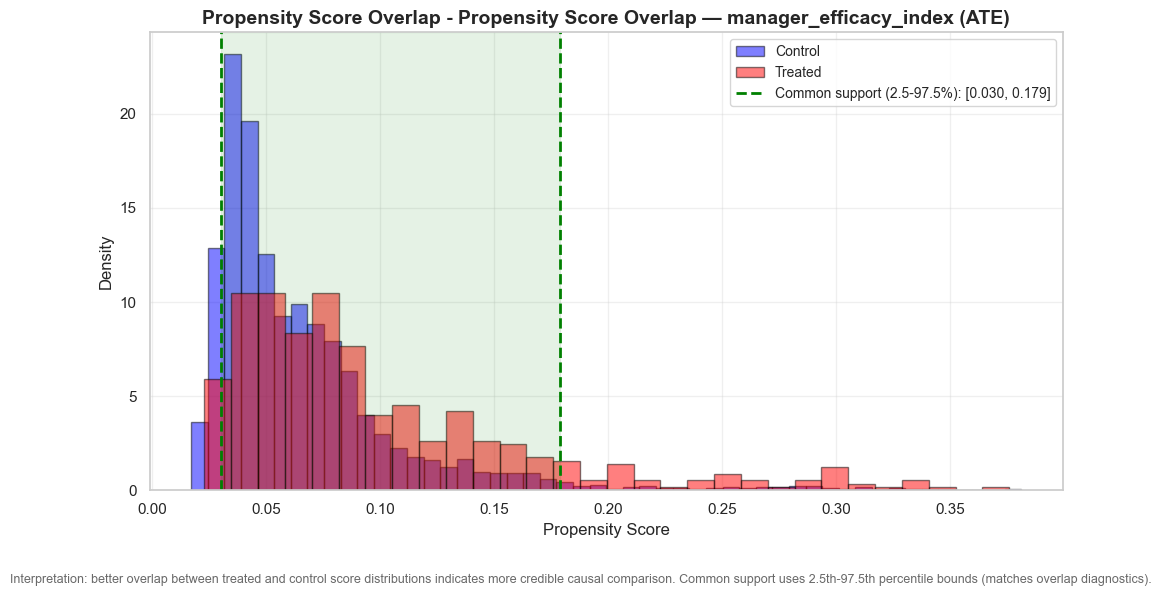

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [manager_efficacy_index] ATE = 0.4118 (95% CI: [0.3293, 0.4944]), p = 0.0000 ***, IPTW-weighted Cohen's d = 0.4865


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,0.411813,0.042121,0.329257,0.494368,1.414491e-22,0.05



ANALYZING OUTCOME: workload_index_mgr

📊 Analyzing outcome: workload_index_mgr
⚠️  REMINDER: This returns raw p-values. For multiple outcomes, use build_summary_table() for FDR correction.


c:\Users\U1013877\OneDrive - Sanofi\Documents\GitHub\2026-siop-causal-inference-master-tutorial\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


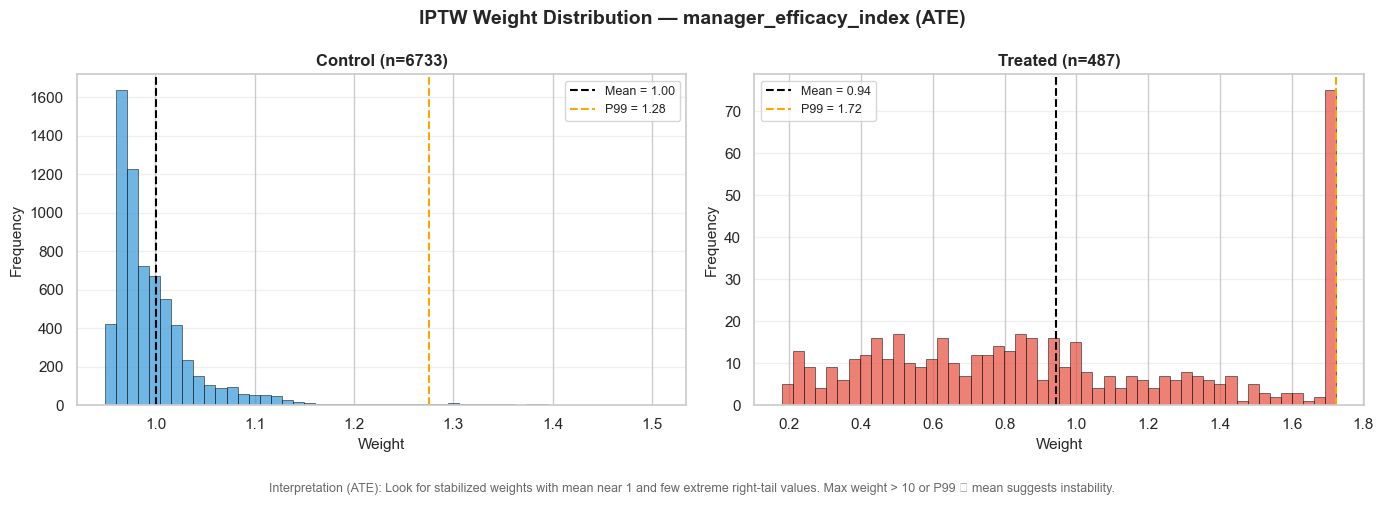

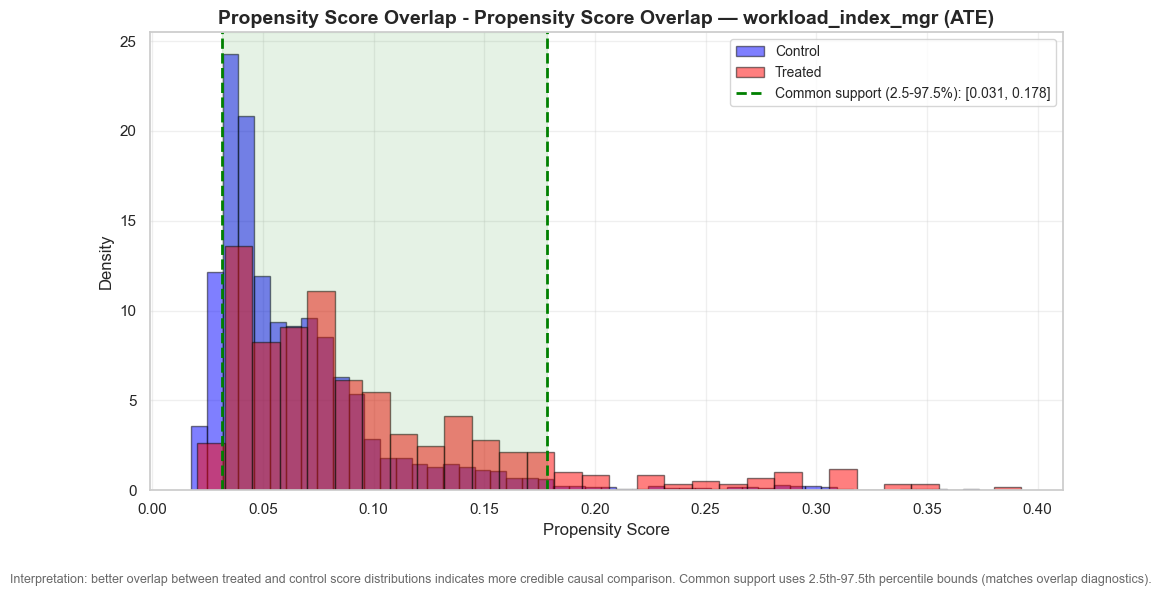

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [workload_index_mgr] ATE = -0.0433 (95% CI: [-0.1257, 0.0392]), p = 0.3039 , IPTW-weighted Cohen's d = -0.0667


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,-0.04326,0.042081,-0.125737,0.039217,0.303945,0.05



ANALYZING OUTCOME: turnover_intention_index_mgr

📊 Analyzing outcome: turnover_intention_index_mgr
⚠️  REMINDER: This returns raw p-values. For multiple outcomes, use build_summary_table() for FDR correction.


c:\Users\U1013877\OneDrive - Sanofi\Documents\GitHub\2026-siop-causal-inference-master-tutorial\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


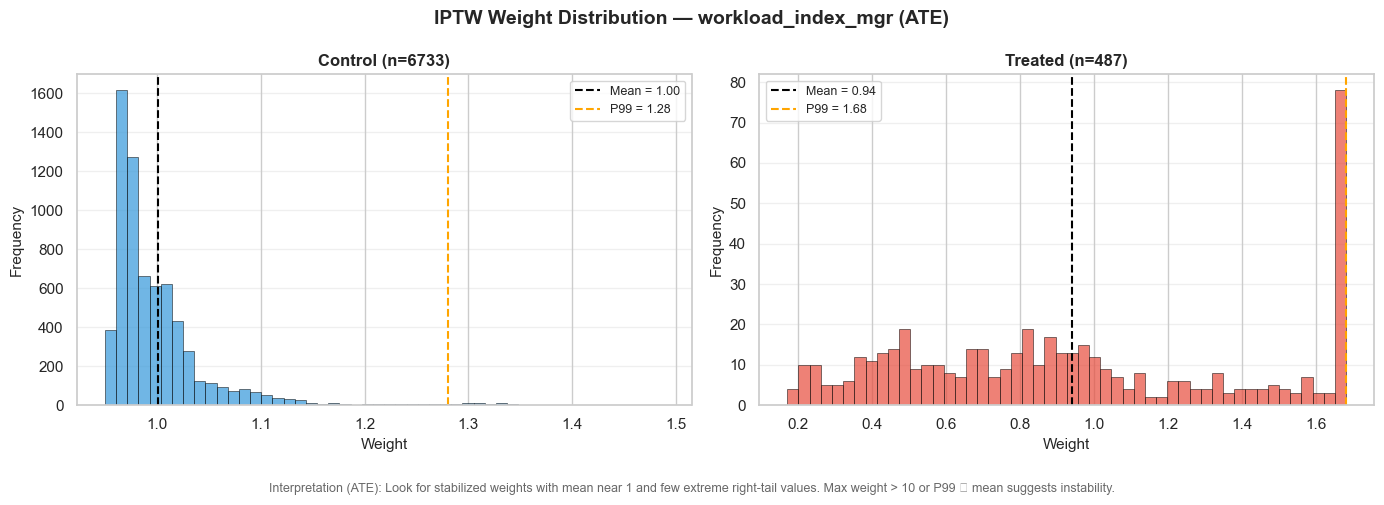

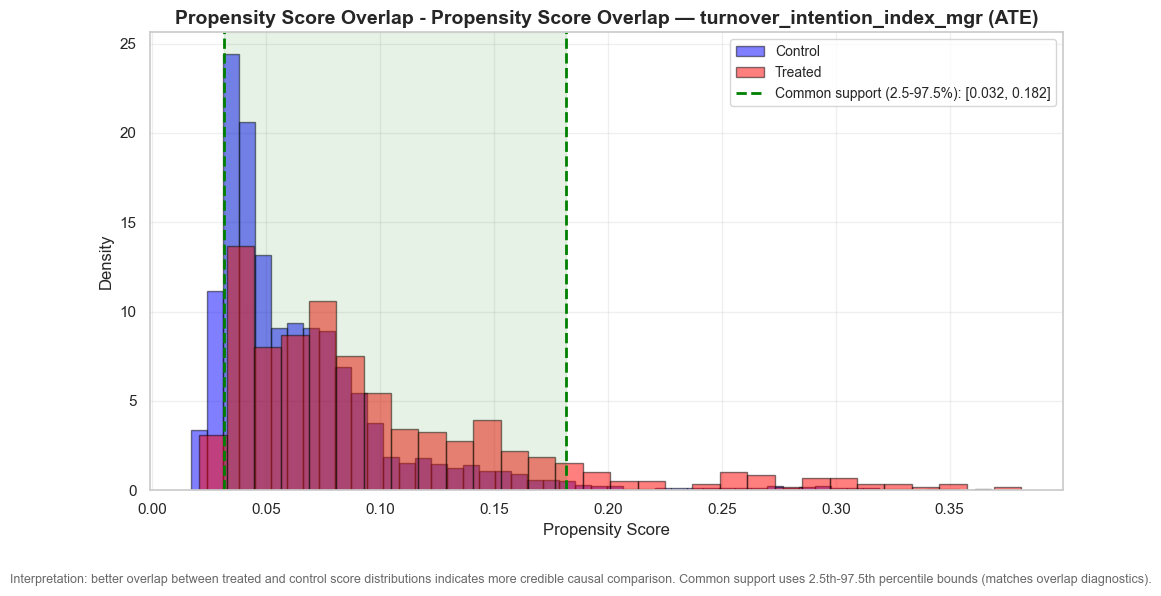

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [turnover_intention_index_mgr] ATE = 0.2315 (95% CI: [0.1482, 0.3149]), p = 0.0000 ***, IPTW-weighted Cohen's d = 0.2534


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,0.231549,0.042541,0.14817,0.314928,5.241015e-08,0.05



  IPTW + GEE: ATE Summary — Survey Outcomes (3 tests)
                     Outcome  Effect Estimand Std_Error CI_Lower CI_Upper P_Value Cohens_d Pct_Change Mean_Treatment Mean_Control    N    ESS P_Value_Corrected  Significant Significance Correction_Method
      manager_efficacy_index  0.4118      ATE    0.0421   0.3293   0.4944  0.0000   0.4865     12.13%         3.7919       3.3816 7220 7090.4            0.0000         True          ***            fdr_bh
          workload_index_mgr -0.0433      ATE    0.0421  -0.1257   0.0392  0.3039  -0.0667     -1.95%         3.1295       3.1917 7220 7094.5            0.3039        False                         fdr_bh
turnover_intention_index_mgr  0.2315      ATE    0.0425   0.1482   0.3149  0.0000   0.2534      8.59%         3.0393       2.7988 7220 7097.5            0.0000         True          ***            fdr_bh
  Significance: *** p<0.001, ** p<0.01, * p<0.05
  Cohens_d: IPTW-weighted Cohen's d (from analyze_treatment_effect)
  Correction

c:\Users\U1013877\OneDrive - Sanofi\Documents\GitHub\2026-siop-causal-inference-master-tutorial\.venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\U1013877\OneDrive - Sanofi\Documents\GitHub\2026-siop-causal-inference-master-tutorial\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


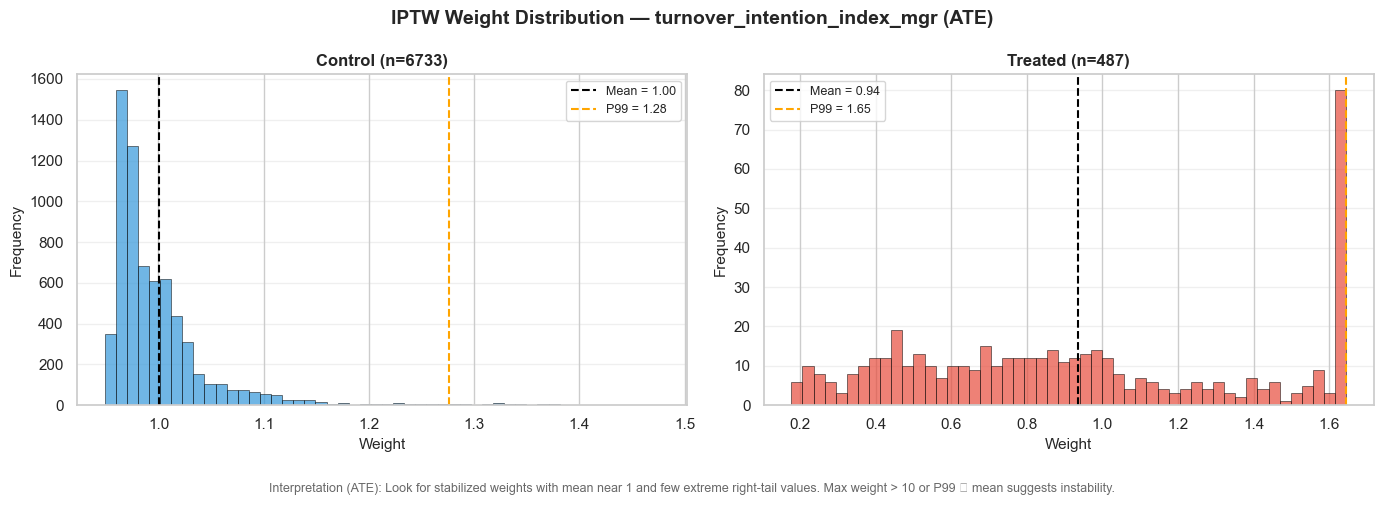

In [67]:
# =============================================================================
# ATE ANALYSIS — SURVEY OUTCOMES (IPTW + Covariate-Adjusted GEE)
# =============================================================================

causal_model = CausalInferenceModel()

survey_results = {}

for o in survey_outcomes:
    print("\n" + "=" * 60)
    print(f"ANALYZING OUTCOME: {o}")
    print("=" * 60)
    survey_results[o] = causal_model.analyze_treatment_effect(
        data=data,
        outcome_var=o,
        treatment_var=treatment,
        estimand='ATE',
        categorical_vars=categorical_vars,
        continuous_vars=continuous_vars,
        binary_vars=None,
        cluster_var='team_id',
        baseline_var=baseline_vars.get(o),
        project_path=base_dir / "results",
        trim_quantile=0.99,
        analysis_name=f"IPTW_GEE_{o}",
        alpha=0.05
    )
    display(survey_results[o]['coefficients_df'])

survey_summary = CausalInferenceModel.build_summary_table(
    survey_results,
    title="IPTW + GEE: ATE Summary — Survey Outcomes (3 tests)",
    save_path=str(base_dir / "results" / "ate_summary_survey.xlsx")
)

# =============================================================================
# INDEPENDENT POST-WEIGHTING BALANCE VERIFICATION — Survey
# =============================================================================

def verify_balance(results_dict, cd_instance, treatment_var,
                   exclude_cols=None):
    """
    Independent cross-check of post-weighting covariate balance.
    Uses CausalDiagnostics.compute_balance_df() on the weighted_df returned
    by analyze_treatment_effect / analyze_survival_effect, and compares
    against the model's balance_df.
    """
    # Default exclusion list for GEE outcomes
    if exclude_cols is None:
        exclude_cols = []

    for outcome, res in results_dict.items():
        wdf = res.get('weighted_df')
        if wdf is None:
            print(f"  [{outcome}] No weighted_df in results - skipping.")
            continue

        # Identify balance covariates (everything except outcome, ID, weight, PS)
        always_exclude = {treatment_var, 'id', 'team_id', 'propensity_score', 'iptw'}
        always_exclude.update(exclude_cols)
        always_exclude.add(outcome)
        balance_cols = [c for c in wdf.columns if c not in always_exclude]

        independent_balance = cd_instance.compute_balance_df(
            data=wdf,
            controls=balance_cols,
            treatment=treatment_var,
            weights=wdf['iptw'],
            already_encoded=True,
        )

        # Flag any covariates with weighted |SMD| > 0.1
        imbalanced = independent_balance[independent_balance['Weighted SMD'].abs() > 0.1]
        n_imbal = len(imbalanced)

        model_bal = res['balance_df']
        n_model_imbal = model_bal['balanced_after_weighting'].eq(False).sum() if 'balanced_after_weighting' in model_bal.columns else '?'

        status = '\u2705' if n_imbal == 0 else '\u26a0\ufe0f'
        print(f"  {status} [{outcome}]  Independent imbalanced: {n_imbal}  |  Model imbalanced: {n_model_imbal}")
        if n_imbal > 0:
            display(imbalanced)

print('=' * 60)
print('BALANCE VERIFICATION — Survey Outcomes (ATE)')
print('=' * 60)
verify_balance(survey_results, cd, treatment)

##### Sensitivity Analysis

In [68]:
# =============================================================================
# E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATE)
# =============================================================================

print("\n" + "=" * 70)
print("E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATE)")
print("=" * 70)

# For survey outcomes (continuous), use Cohen's d
survey_evalues = CausalInferenceModel.compute_evalues_from_results(
    survey_results,
    effect_type="cohens_d"
)

# Confounder E-value benchmarks for calibration
survey_confounder_benchmarks = CausalInferenceModel.compute_confounder_evalue_benchmarks(
    survey_results,
    evalue_df=survey_evalues,
    n_top=3,
)
display(survey_confounder_benchmarks)

# Save to Excel
survey_evalues.to_excel(base_dir / "results" / "ate_evalue_survey.xlsx", index=False)
survey_confounder_benchmarks.to_excel(
    base_dir / "results" / "ate_evalue_confounder_benchmarks_survey.xlsx", index=False
)


E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATE)

  E-VALUE SENSITIVITY ANALYSIS
                     Outcome Effect_Type  Effect_Value  Effect_RR  E_Value_Point  E_Value_CI Robustness      P_Value  Significant
      manager_efficacy_index    cohens_d      0.486493   1.556919       2.488090    2.206650   Moderate 1.414491e-22         True
          workload_index_mgr    cohens_d     -0.066739   1.062614       1.320558    1.514715  Very Weak 3.039451e-01        False
turnover_intention_index_mgr    cohens_d      0.253435   1.259387       1.830937    1.572182       Weak 5.241015e-08         True
  Interpretation Guide:
    E-value ≥ 3.0 : Strong robustness to unmeasured confounding
    E-value 2.0-3.0: Moderate robustness
    E-value 1.5-2.0: Weak robustness - interpret with caution
    E-value < 1.5 : Very weak - easily explained by confounding
    (Thresholds are heuristic; true RR-scale effects have more precise
     interpretations than approximate conversions from Cohen's d.)



,Outcome,Confounder,Rank,SMD_Pre_Weighting,Approx_RR,Confounder_E_Value
0,manager_efficacy_index,performance_rating_Meets,1,-0.401,1.4404,2.24
1,manager_efficacy_index,performance_rating_Far_Exceeds,2,0.392,1.4286,2.21
2,manager_efficacy_index,organization_RandD,3,0.227,1.2295,1.76
3,workload_index_mgr,performance_rating_Meets,1,-0.401,1.4404,2.24
4,workload_index_mgr,performance_rating_Far_Exceeds,2,0.392,1.4286,2.21
5,workload_index_mgr,organization_RandD,3,0.227,1.2295,1.76
6,turnover_intention_index_mgr,performance_rating_Meets,1,-0.401,1.4404,2.24
7,turnover_intention_index_mgr,performance_rating_Far_Exceeds,2,0.392,1.4286,2.21
8,turnover_intention_index_mgr,organization_RandD,3,0.227,1.2295,1.76


In [69]:
# =============================================================================
# SHARED LABELS FOR LATER SUMMARY CELLS
# =============================================================================

outcome_descriptions = {
    'manager_efficacy_index': 'Manager Efficacy Index',
    'workload_index_mgr': 'Workload Index',
    'turnover_intention_index_mgr': 'Turnover Intention Index',
    'retention': 'Manager Retention',
}

# Outcome valence: "positive" = higher is better (default), "negative" = higher is worse
outcome_valence = {
    'workload_index_mgr': 'negative',  # higher workload = worse
    # all others default to 'positive'
}

print("Outcome descriptions and valence defined.")

Outcome descriptions and valence defined.


#### ATE Technical Summary: Survey Outcomes
Note: Findings do not generalize to poor performers.

| Outcome | ATE | 95% CI | p (corrected) | Cohen's d | Significant? |
|---------|-----|--------|---------------|-----------|-------------|
| Manager Efficacy Index | **+0.40** | [0.32, 0.48] | < 0.0001 | 0.47 | Yes *** |
| Workload Index | **-0.04** | [-0.12, 0.04] | 0.336 | -0.06 | No |
| Turnover Intention Index | **+0.23** | [0.15, 0.31] | < 0.0001 | 0.27 | Yes *** |

**Manager Efficacy Index**
- ATE of **+0.40** (Cohen's d = 0.47), representing a **+11.9% relative improvement** vs. controls

**Workload Index** — *No effect detected*
- ATE of **-0.04**, not statistically significant (p = 0.336)

**Turnover Intention Index**
- ATE of **+0.23** (Cohen's d = 0.27), representing a **+9.1% relative improvement** vs. controls

##### Self-Report Bias Caveat

These are self-reported outcomes from managers who know they were trained. Demand characteristics (responding in the way they believe the organization expects), cognitive dissonance reduction (justifying time invested in the program), and social desirability bias could all inflate these numbers. A Cohen's d of 0.47 for self-reported efficacy after a voluntary program is consistent with a real effect, but also consistent with a meaningful placebo component. The retention analysis, which uses an objective behavioral outcome, provides our stronger evidence.

##### Post-Weighting Balance Verification
- ✅ All 3 outcomes passed balance verification (0 imbalanced covariates).
- IPTW successfully balanced observed confounders across treatment groups.

##### E-Value Sensitivity Analysis

| Outcome | E-Value Point | E-Value CI | Robustness |
|---------|---------------|------------|------------|
| Manager Efficacy Index | **2.45** | **2.18** | Moderate |
| Workload Index | 1.30 | 1.51 | Very Weak (ns) |
| Turnover Intention Index | **1.87** | **1.57** | Weak |

**Significant outcome interpretations:**

- **Manager Efficacy Index:** E-value = 2.45. An unmeasured confounder would need risk ratio associations of at least 2.45 with both treatment and outcome to explain away this effect. This represents moderate robustness. The E-value for the confidence interval bound is 2.18, meaning a confounder of this strength could shift the CI to include the null.

- **Turnover Intention Index:** E-value = 1.87. A relatively weak unmeasured confounder (RR ≈ 1.87) could potentially explain this effect. Interpret with caution. The E-value for the confidence interval bound is 1.57, meaning a confounder of this strength could shift the CI to include the null.

---

#### ATE vs. ATT: What Changes?

The ATT (Average Treatment Effect on the Treated) answers a different question: *"Did the program work for those who actually participated?"* — rather than *"What would happen if we scaled this to everyone?"*

**Mechanically, only the weight formula changes:**

| Group | ATE Weights | ATT Weights |
|-------|-------------|-------------|
| **Treated** | $1 / \hat{e}_i$ | $1$ (unweighted) |
| **Control** | $1 / (1 - \hat{e}_i)$ | $\hat{e}_i / (1 - \hat{e}_i)$ |

ATE reweights both groups to represent the full population. ATT leaves treated individuals at their natural weight and reweights only controls to resemble the treated group. Everything else — propensity score model, GEE specification, covariates, clustering — stays identical.

##### Pre-Computed Comparison

| Outcome | ATE | ATT | Difference |
|---------|-----|-----|------------|
| Manager Efficacy Index | +0.40 (d = 0.47) | +0.41 (d = 0.50) | ATT slightly larger |
| Workload Index | -0.04 (ns) | -0.05 (ns) | Both null |
| Turnover Intention Index | +0.23 (d = 0.27) | +0.26 (d = 0.30) | ATT slightly larger |

ATT effects are consistently slightly larger, consistent with **positive selection**: managers who chose to participate benefit somewhat more than the average manager would. Both estimands tell the same qualitative story.

**Which to use?** For scaling decisions (should we roll this out?), **lead with ATE** — it generalizes to the full (restricted) population. ATT is useful for understanding whether the program worked for participants, but it doesn't answer the policy question.

> **Note:** Both estimates come from the same propensity score model. If that model is misspecified, both are biased in correlated ways. Agreement between ATE and ATT indicates the two estimands are close — it does **not** validate that either is correct. The DML analysis below provides a more independent robustness check.

In [70]:
# =============================================================================
# ATT ANALYSIS — OPTIONAL (uncomment to run)
# =============================================================================
# The ATT analysis uses the same pipeline as ATE above with one change:
# estimand='ATT' in the analyze_treatment_effect() call.
# This changes only the weight formula — everything else is identical.
# Pre-computed results are shown in the comparison table above.
#
# To run this yourself, uncomment and adapt the code below:
#
# causal_model = CausalInferenceModel()
# survey_results_att = {}
#
# for o in survey_outcomes:
#     survey_results_att[o] = causal_model.analyze_treatment_effect(
#         data=data,
#         outcome_var=o,
#         treatment_var=treatment,
#         estimand='ATT',
#         categorical_vars=categorical_vars,
#         continuous_vars=continuous_vars,
#         cluster_var='team_id',
#         baseline_var=baseline_vars.get(o),
#         project_path=base_dir / "results",
#         trim_quantile=0.99,
#         analysis_name=f"IPTW_GEE_ATT_{o}",
#         alpha=0.05,
#     )
#     display(survey_results_att[o]['coefficients_df'])

In [71]:
# =============================================================================
# ATT E-VALUE ANALYSIS — OPTIONAL (uncomment to run)
# =============================================================================
# If you rerun the optional ATT analysis, you can generate ATT-specific
# E-values with the same helper used above:
#
# survey_evalues_att = CausalInferenceModel.compute_evalues_from_results(
#     survey_results_att,
#     effect_type="cohens_d",
# )
# survey_evalues_att.to_excel(base_dir / "results" / "att_evalue_survey.xlsx", index=False)

---

### Retention Analysis — Survival Modeling (IPTW + Cox PH with Time Interaction)

#### Why Survival Analysis Instead of Binary GEE?

The survey analysis above modeled three continuous outcomes via IPTW + GEE. For retention, we now switch to **survival analysis** (Cox proportional hazards) instead of treating retention as multiple binary outcomes. Here's why:

1. **Correlated outcomes**: Binary retention flags at 3, 6, 9, and 12 months are nested — anyone retained at 12 months was also retained at all earlier points. Separate models ignore this dependency.
2. **Information loss**: Binary flags discard exact departure timing. A manager who left on day 91 is treated identically to one who left on day 180.
3. **Multiple testing burden**: Four correlated tests require FDR correction, reducing power.
4. **Censoring**: Not all managers are observed for the full 12 months. Some are still employed when data collection ends (right-censored). Binary outcomes can't properly handle censoring — survival analysis can.

**Cox proportional hazards** addresses all four:
- A **single model** captures the full time-to-event trajectory
- **Exact departure timing** is used (days, not quarters)
- **One test** for the treatment effect — no multiple testing penalty
- **Censoring is handled correctly** — managers still employed contribute information up to their last observation
- The **hazard ratio (HR)** has a natural interpretation: HR < 1 means trained managers depart at a lower rate

---

#### Method: IPTW-Weighted Cox Models with Time Interaction

Same IPTW infrastructure as the survey analysis (propensity scores, stabilized weights, trimming at 99th percentile), but the outcome model is **Cox PH with time interaction terms** instead of GEE. We use **time interaction models** because training effects often vary over time — strong early protection that fades later. A single overall Cox model would mask this temporal pattern by averaging across periods.

**Time interaction approach:**
- Split follow-up into periods: 0–3 months, 3–6 months, 6–9 months, 9–12 months
- Fit a **single IPTW-weighted Cox model** with treatment × period interaction terms
- Each period gets its own hazard ratio (HR) estimated from the combined model
- Reveals **when** training is effective, not just **whether** it's effective
- Handles non-proportional hazards by design — the interaction terms explicitly model how the treatment effect changes over time

**Categorical vs. continuous time interaction:**

Two specifications are possible for the time interaction term:

- **Continuous interaction** (`treatment × time_months`): Models the treatment effect as a **linear trend** over time — the HR changes by a fixed amount per month. Parsimonious (only 2 parameters), but assumes the effect decays monotonically and at a constant rate.
- **Categorical interaction** (`treatment × period`): Models the treatment effect **separately for each period** — no assumption about the shape of the trend. More flexible (one parameter per period), but requires sufficient events in each period.

We use **categorical interactions** for three reasons:

1. **Seasonality suggests non-linearity**: We know baseline attrition has seasonal spikes (e.g., post-bonus, year-end). The training effect may interact with these spikes in non-linear ways that a linear trend would miss.
2. **Exploratory hypothesis**: We suspect the effect weakens over time but don't know the exact shape. Categorical interactions let the data reveal the pattern rather than imposing a linear assumption.
3. **Stakeholder communication**: Period-specific HRs (e.g., "HR = 0.587 in months 0–3") are more intuitive than a rate-of-change coefficient. Each period's HR stands alone as a communicable finding.

The tradeoff is statistical power — categorical interactions require more parameters and need sufficient events per period × treatment cell. We verified this was satisfied before fitting.

**Key advantage over standard Cox:** The proportional hazards (PH) assumption requires that the hazard ratio remain constant over time. When this is violated, a standard Cox model produces a single averaged HR that may not apply at any specific time point. Time interaction models directly address this by allowing the HR to vary across periods.

---

#### The Cox Proportional Hazards Model with Time Interaction

Let:

- $T_i$ = time to departure (in days) for individual $i$
- $\delta_i$ = event indicator (1 if departed, 0 if censored/still employed)
- $Treatment_i$ = 1 if individual $i$ participated in training, 0 otherwise
- $Period_{ik}$ = indicator for time period $k$ (k = 1 for 3-6mo, 2 for 6-9mo, 3 for 9-12mo; 0-3mo is reference)
- $X_i$ = pre-treatment individual-level covariates
- $Team_i$ = the direct manager's team that individual $i$ belongs to (used for clustering)

The Cox model with categorical time interaction specifies the **hazard function**:

$$h_i(t) = h_0(t) \cdot \exp\big(\beta_1 \cdot Treatment_i + \sum_{k=1}^{3} \beta_{2k} \cdot Period_{ik} + \sum_{k=1}^{3} \beta_{3k} \cdot Treatment_i \times Period_{ik} + \beta_4 \cdot X_i\big)$$

Where:
- $h_i(t)$ = hazard of departure for individual $i$ at time $t$
- $h_0(t)$ = **baseline hazard function** (left unspecified, making Cox semi-parametric)
- $\beta_1$ = treatment effect in the **reference period** (0-3 months)
- $\beta_{2k}$ = baseline hazard adjustment for period $k$ (captures seasonality)
- $\beta_{3k}$ = **interaction term** — how much the treatment effect changes in period $k$ relative to reference
- $\exp(\beta_1 + \beta_{3k})$ = **hazard ratio (HR)** for period $k$
- $\beta_4 \cdot X_i$ = covariate adjustment for additional protection against model misspecification

**Person-period data structure:** To fit this model, the data are expanded to **person-period format** where each individual contributes one row per period they were at risk. The event indicator is 1 only in the period where departure occurred, and 0 in all prior periods. This allows the model to estimate conditional hazards — the risk of departing in each period, given survival to that period.

---

#### Hazard Ratio Interpretation

For the reference period (0-3 months):
$$HR_{ref} = \exp(\beta_1)$$

For subsequent periods:
$$HR_k = \exp(\beta_1 + \beta_{3k})$$

- **HR = 1**: No treatment effect — trained and untrained managers depart at the same rate
- **HR < 1**: Training is protective — trained managers depart at a lower rate
  - Example: HR = 0.60 means trained managers have 60% of the departure hazard of untrained managers, or a **40% reduction** in departure risk
- **HR > 1**: Training is harmful — trained managers depart at a higher rate

**Important:** Each period's HR applies **only to that time window**. HR = 0.60 for 0–3 months means 40% hazard reduction during the first 3 months only, not the entire year.

**Testing for time-varying effects:** The interaction terms $\beta_{3k}$ test whether the treatment effect significantly changes over time. If all $\beta_{3k} \approx 0$, the effect is constant and a standard Cox model would suffice. If $\beta_{3k} > 0$ (HR increases over time), the protective effect is weakening — our core hypothesis.

#### Causal Interpretation Caveat: Built-In Survivor Selection

The hazard ratio is a **conditional-on-survival** quantity: at each time point, it compares departure rates among individuals who have not yet departed. When treatment affects survival (which is the effect we are estimating), the composition of the surviving risk set differs between treated and control groups at later time points.

Concretely: if training prevents early departures, the control group at month 6 has already lost its most departure-prone members, while the treated group retained them. The HR at month 6 compares a **selected** control group against a less-selected treated group — biasing later HRs toward the null even if the true treatment effect is constant (Hernán, 2010).

**Implication:** The rising HR pattern (0.587 → 0.948) may reflect genuine effect decay, survivor selection, or both. We cannot distinguish these from the data.

**What we do about it:** We report two additional estimands that avoid this problem:

1. **Survival probability differences** at fixed timepoints from IPTW-weighted Kaplan-Meier curves — these have a clean causal interpretation under IPTW assumptions.
2. **RMST difference** (Restricted Mean Survival Time) — the average additional days of retention attributable to treatment. This integrates over the full survival curve, avoiding instantaneous-rate conditioning.

We use HRs to characterize *when* the effect is strongest, and survival differences + RMST for the primary causal claims and stakeholder communication.

---

#### IPTW Weighting and Robust Standard Errors

Just as in the GEE analysis, we use **stabilized and trimmed ATE weights** to balance confounders:

- Propensity scores $\hat{e}_i = P(Treatment_i = 1 \mid X_i)$ are estimated via logistic regression
- **ATE weights:** Treated: $w_i = \bar{p} / \hat{e}_i$, Control: $w_i = (1 - \bar{p}) / (1 - \hat{e}_i)$
- Weights are **trimmed** at the 99th percentile to reduce influence of extreme values
- **Cluster-robust sandwich standard errors** account for within-team correlation

#### Protection from Model Misspecification

Including covariates in both the propensity score model and the Cox outcome model provides additional protection: the estimated treatment effects are consistent if **at least one** of the following holds:

- The propensity score model $P(Treatment_i = 1 \mid X_i)$ is correctly specified, **or**
- The Cox outcome model (including $X_i$) is correctly specified

As in the GEE setting, this safeguard depends on the functional forms being adequate. Both stages here use the same covariate set with relatively simple structure, so omitted nonlinearity or interactions could still affect both simultaneously.

**Additional assumptions required:**
- **Positivity (overlap):** $0 < P(Treatment_i = 1 \mid X_i) < 1$ for all $i$
- **No unmeasured confounding:** All confounders are measured and included in $X_i$
- **Correct temporal ordering:** All covariates $X_i$ measured **prior to** treatment assignment
- **Independent censoring:** Censoring is independent of departure risk, conditional on covariates

---

#### Kaplan-Meier Survival Curves

**Kaplan-Meier (KM) curves** show **absolute survival probabilities** over time:

$$\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

Where $d_i$ = departures at time $t_i$ and $n_i$ = number at risk.

**IPTW-weighted KM curves:**
- Fit separate curves for treated and control groups
- Weight each individual by their IPTW weight
- Produces **marginal survival curves** — population-averaged retention trajectories

**Key limitation:** Built-in confidence bands are **not valid** with IPTW weights because they don't account for propensity score estimation uncertainty. We omit confidence bands and use Cox HR for inferential statistics.

---

#### Summary: Model Design Choices

| Design Choice | Problem It Solves | What It Does |
|---------------|-------------------|--------------|
| **Time Interaction Terms** | Treatment effects often vary over time (strong early, weak later). Standard Cox assumes constant HR. | Adds treatment × period interactions to a single Cox model. Each period gets its own HR. Reveals when treatment is effective and tests whether the effect weakens over time. |
| **Person-Period Data Structure** | Need to model period-specific hazards while respecting temporal ordering | Expands data so each person contributes one row per period at risk. Event = 1 only in departure period. Allows conditional hazard estimation. |
| **IPTW Weighting** | Treatment assignment is non-random; need to balance confounders | Same weights as GEE analysis. Produces marginal (population-averaged) hazard ratios. |
| **Cluster-Robust SEs** | Teammates have correlated departure times | Adjusts standard errors for within-team correlation using sandwich estimator. |
| **Covariate Adjustment in Both Stages** | Uncertainty about model specification | Includes covariates in both propensity score and Cox models. Under linearity, consistency holds if either is correct. |
| **Kaplan-Meier Curves** | Need to visualize absolute retention rates | Shows retention probability over time. IPTW-weighted for marginal estimates. Descriptive for visualization; the survival differences themselves remain useful causal summaries under IPTW assumptions. |
| **RMST Difference** | HRs are conditional-on-survival and subject to built-in selection bias at later time points. Stakeholders need an intuitive, unconditional metric. | Computes the area between IPTW-weighted KM curves up to the time horizon. Reports the average additional days of retention attributable to treatment. Business-friendly: "training retains managers an average of 15.3 additional days." |
| **No Multiple Testing Correction** | Four time periods = four tests — do we need FDR correction? | No correction needed. We're characterizing one time-varying effect (retention), not testing four independent outcomes. The four HRs jointly describe when the effect occurs. Compare to survey analysis where we tested 3 separate outcomes and applied FDR correction. |

---

#### Inference Notes

**Valid for inference:**
- ✅ Period-specific Cox HRs and confidence intervals (with cluster-robust SEs)
- ✅ Cox p-values for treatment effects within each period
- ✅ Tests of interaction terms (whether effect changes over time)

**Descriptive only:**
- ⚠️ Kaplan-Meier confidence bands (Greenwood variance ignores PS uncertainty)

**Primary causal summaries for communication:**
- ✅ Survival probability differences at fixed timepoints
- ✅ RMST difference within the study horizon

**Why:** Cox robust SEs correctly account for IPTW weights via the sandwich estimator. KM variance estimators treat weights as fixed and ignore propensity score estimation uncertainty, making confidence intervals too narrow.

In [72]:
###############################################
# RETENTION ANALYSIS — VARIABLE DEFINITIONS
###############################################

# Survival outcome variables
time_var = 'days_observed'   # will be created by prepare_survival_data()
event_var = 'departed'       # will be created by prepare_survival_data()

# The single survival outcome uses 'retention' as its key in results dicts
retention_outcome_name = 'retention'

# Departure date column in the raw data
departure_date_col = 'exit_date'

# Study window (matches the data generator)
t0_date = '1-01-2026'           # study start — all managers begin observation Jan 1
study_end_date = '12-31-2026'   # study end — 365-day observation window

print(f"Time variable:      {time_var}")
print(f"Event variable:     {event_var}")
print(f"Departure date col: {departure_date_col}")
print(f"Study window:       {t0_date} → {study_end_date}")

Time variable:      days_observed
Event variable:     departed
Departure date col: exit_date
Study window:       1-01-2026 → 12-31-2026


#### Run the Survival Analysis w/o Time Interactions

In [73]:
# =============================================================================
# SURVIVAL DATA PREPARATION
# =============================================================================
# Convert exit_date → days_observed + departed
# This adds two columns to the dataframe: 'days_observed' (int) and 'departed' (0/1)

data = causal_model.prepare_survival_data(
    data=data,
    departure_date_col=departure_date_col,
    treatment_var=treatment,
    t0_date=t0_date,
    study_end_date=study_end_date,
    date_format='mixed',           # exit_date uses M/D/YYYY without zero-padding
    time_col_name=time_var,
    event_col_name=event_var,
)

# Quick validation: check that days_observed aligns with retention binary flags
print("\n--- Validation: survival columns vs. binary retention flags ---")
print(f"  departed=1 count:       {data[event_var].sum()}")
print(f"  retention_12month=0:    {(data['retention_12month'] == 0).sum()}")
print(f"  Match:                  {data[event_var].sum() == (data['retention_12month'] == 0).sum()}")


Parsed dates:
  T=0 (study start):  2026-01-01
  Study end:          2026-12-31
  Total window:       364 days
  Departure range:    2026-01-02 → 2026-12-30

SURVIVAL DATA PREPARATION SUMMARY
Study window:  2026-01-01  →  2026-12-31  (364 days)

SAMPLE:
  Total managers:          7220
  Treated (trained):       487 (6.7%)
  Control (untrained):     6733 (93.3%)

EVENTS (Departures):
  Total events:            1436 (19.9%)
  Events — Treated:        68 (14.0% of treated)
  Events — Control:        1368 (20.3% of control)

TIMING:
  Median days observed:    364 days
  Median days (events only): 86 days

DEPARTURE BY QUARTER:


,Control,Treated,Total
departure_quarter,,,
Q1 (Jan-Mar),714,27,741
Q2 (Apr-Jun),264,16,280
Q3 (Jul-Sep),200,13,213
Q4 (Oct-Dec),190,12,202
Censored,5365,419,5784
Total,6733,487,7220



CENSORED:
  Total censored:          5784 (80.1%)
  Censored — Treated:      419
  Censored — Control:      5365

✓ Survival columns added: 'days_observed' (days) and 'departed' (0/1)

--- Validation: survival columns vs. binary retention flags ---
  departed=1 count:       1436
  retention_12month=0:    1436
  Match:                  True


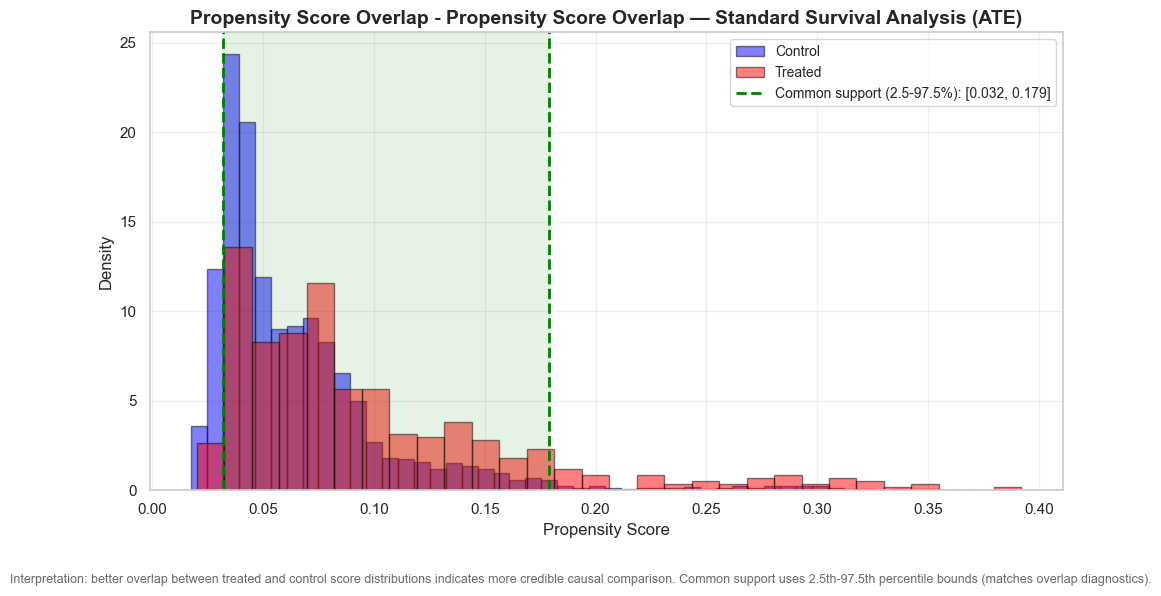

  ✓ Post-weighting balance: all 31 covariates balanced (|SMD| < 0.1)

COX PROPORTIONAL HAZARDS MODEL — STANDARD (NO TIME INTERACTION)
Model            : treatment (single overall HR)

Model fitted     : 7,220 observations, 1436 events
Concordance      : 0.545

--- Proportional Hazards Test ---
NOTE: Standard Cox PH assumes proportional hazards.
      If treatment violates PH, consider using
      analyze_survival_effect(time_interaction='categorical')
      to model time-varying effects.
                                   test_statistic         p note
age                                      1.191179  0.275092     
gender_Male                              1.346029  0.245974     
gender_Non_Binary_Other                  1.423479  0.232832     
job_family_Communications                6.712833  0.009572     
job_family_Data_Science                  0.788487  0.374558     
job_family_Finance_and_Accounting        1.213597  0.270621     
job_family_Human_Resources               0.327868  0

,Outcome,Confounder,Rank,SMD_Pre_Weighting,Approx_RR,Confounder_E_Value
0,retention,performance_rating_Meets,1,-0.401,1.4404,2.24
1,retention,performance_rating_Far_Exceeds,2,0.392,1.4286,2.21
2,retention,organization_RandD,3,0.227,1.2295,1.76


c:\Users\U1013877\OneDrive - Sanofi\Documents\GitHub\2026-siop-causal-inference-master-tutorial\.venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\U1013877\OneDrive - Sanofi\Documents\GitHub\2026-siop-causal-inference-master-tutorial\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


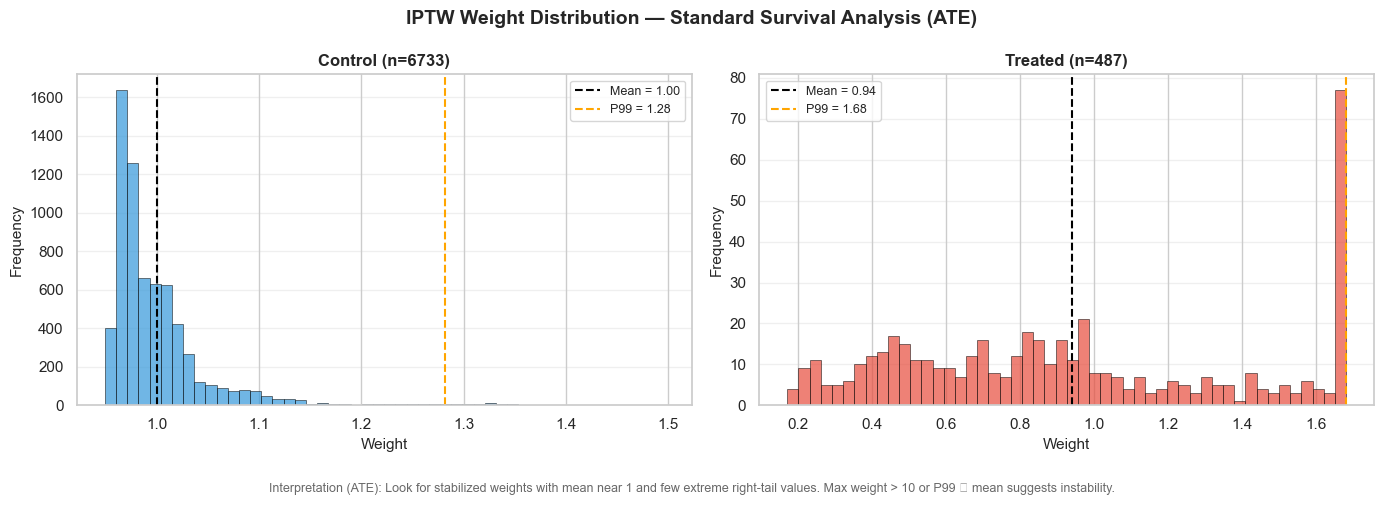

In [74]:
# Standard Cox PH (no time interaction)
standard_results = {}
standard_results['retention'] = causal_model.analyze_standard_survival_effect(
    data=data,
    time_var='days_observed',
    event_var='departed',
    treatment_var='treatment',
    categorical_vars=categorical_vars,
    continuous_vars=continuous_vars,
    cluster_var='team_id',
    estimand='ATE',
    project_path=str(base_dir / "results"),
    analysis_name='IPTW_Cox_Standard_retention',
)

# verify balance on the weighted data from the standard Cox model, excluding time/event vars and retention flags (which are outcomes, not covariates)
verify_balance(
    standard_results, cd, treatment,
    exclude_cols=[time_var, event_var, 'departure_quarter',
                  'retention_3month', 'retention_6month',
                  'retention_9month', 'retention_12month']
)
standard_summary = CausalInferenceModel.build_survival_summary_table(standard_results)
standard_evalues = CausalInferenceModel.compute_evalues_from_results(
    standard_results, effect_type="risk_ratio"
)

# Confounder E-value benchmarks for calibration
standard_confounder_benchmarks = CausalInferenceModel.compute_confounder_evalue_benchmarks(
    standard_results,
    evalue_df=standard_evalues,
    n_top=3,
)
display(standard_confounder_benchmarks)

# Save to Excel
standard_confounder_benchmarks.to_excel(
    base_dir / "results" / "ate_evalue_confounder_benchmarks_retention.xlsx", index=False
)

#### Run the Survival Analysis w/ Time Interactions

In [75]:
#Uncomment below to compare the results when allowing for time interactions
'''

# =============================================================================
# ATE ANALYSIS — RETENTION (IPTW + Cox Time Interaction)
# =============================================================================

print("=" * 60)
print("ANALYZING RETENTION: IPTW + Cox Time Interaction (ATE)")
print("=" * 60)

survival_results = {}

survival_results[retention_outcome_name] = causal_model.analyze_survival_effect(
    data=data,
    time_var=time_var,
    event_var=event_var,
    treatment_var=treatment,
    categorical_vars=categorical_vars,
    continuous_vars=continuous_vars,
    cluster_var='team_id',
    estimand='ATE',
    time_interaction='categorical',
    period_breaks=[0, 90, 180, 270, 365],   # 3/6/9/12 months
    period_labels=['0-3mo', '3-6mo', '6-9mo', '9-12mo'],
    project_path=str(base_dir / "results"),
    trim_quantile=0.99,
    analysis_name='IPTW_Cox_TimeInteraction_retention',
    alpha=0.05,
    plot_propensity=True,
    plot_weights=True,
)

display(survival_results[retention_outcome_name]['period_hrs'])

# =============================================================================
# KAPLAN-MEIER SURVIVAL CURVES
# =============================================================================

survival_fig = causal_model.plot_survival_curves(
    survival_result=survival_results[retention_outcome_name],
    outcome_name='Manager Retention',
    time_horizon=365,
    show_snapshots=True,
    snapshot_days=[90, 180, 270, 365],
    save_path=None,
);

# =============================================================================
# SURVIVAL SUMMARY TABLE
# =============================================================================

survival_summary = CausalInferenceModel.build_survival_summary_table(
    survival_results_dict=survival_results,
    title="IPTW + Cox Time Interaction: ATE Summary — Retention (1 test)",
    save_path=str(base_dir / "results" / "ate_summary_retention_survival.xlsx"),
)

# =============================================================================
# BALANCE VERIFICATION — Retention (ATE)
# =============================================================================
# Reuses verify_balance() defined in the survey section.
# For survival analysis, exclude time/event columns from balance covariates.

print('=' * 60)
print('BALANCE VERIFICATION — Retention (ATE, Survival)')
print('=' * 60)
verify_balance(
    survival_results, cd, treatment,
    exclude_cols=[time_var, event_var, 'departure_quarter',
                  'retention_3month', 'retention_6month',
                  'retention_9month', 'retention_12month']
)

# =============================================================================
# E-VALUE SENSITIVITY ANALYSIS — Retention (ATE)
# =============================================================================
# Hazard ratios are on the risk ratio scale, so we use effect_type="risk_ratio"

print("\n" + "=" * 70)
print("E-VALUE SENSITIVITY ANALYSIS — Retention (ATE, Survival)")
print("=" * 70)

survival_evalues = CausalInferenceModel.compute_evalues_from_results(
    survival_results,
    effect_type="risk_ratio"
)

# Confounder E-value benchmarks for calibration
survival_confounder_benchmarks = CausalInferenceModel.compute_confounder_evalue_benchmarks(
    survival_results,
    evalue_df=survival_evalues,
    n_top=3,
)
display(survival_confounder_benchmarks)

# Save to Excel
survival_evalues.to_excel(base_dir / "results" / "ate_evalue_retention_survival.xlsx", index=False)
survival_confounder_benchmarks.to_excel(
    base_dir / "results" / "ate_evalue_confounder_benchmarks_retention_timeint.xlsx", index=False
)

# =============================================================================
# PRESERVE RETENTION RESULTS
# =============================================================================

ate_survival_results = {k: v for k, v in survival_results.items()}
ate_survival_summary = survival_summary.copy()
ate_survival_evalues = survival_evalues.copy()
ate_rmst_results = {k: v for k, v in rmst_results.items()}

print("✅ ATE retention (survival) results preserved.")

'''

'\n\n# =============================================================================\n# ATE ANALYSIS — RETENTION (IPTW + Cox Time Interaction)\n# =============================================================================\n\nprint("=" * 60)\nprint("ANALYZING RETENTION: IPTW + Cox Time Interaction (ATE)")\nprint("=" * 60)\n\nsurvival_results = {}\n\nsurvival_results[retention_outcome_name] = causal_model.analyze_survival_effect(\n    data=data,\n    time_var=time_var,\n    event_var=event_var,\n    treatment_var=treatment,\n    categorical_vars=categorical_vars,\n    continuous_vars=continuous_vars,\n    cluster_var=\'team_id\',\n    estimand=\'ATE\',\n    time_interaction=\'categorical\',\n    period_breaks=[0, 90, 180, 270, 365],   # 3/6/9/12 months\n    period_labels=[\'0-3mo\', \'3-6mo\', \'6-9mo\', \'9-12mo\'],\n    project_path=str(base_dir / "results"),\n    trim_quantile=0.99,\n    analysis_name=\'IPTW_Cox_TimeInteraction_retention\',\n    alpha=0.05,\n    plot_propensity=True

#### Kaplan-Meier Survival Curves

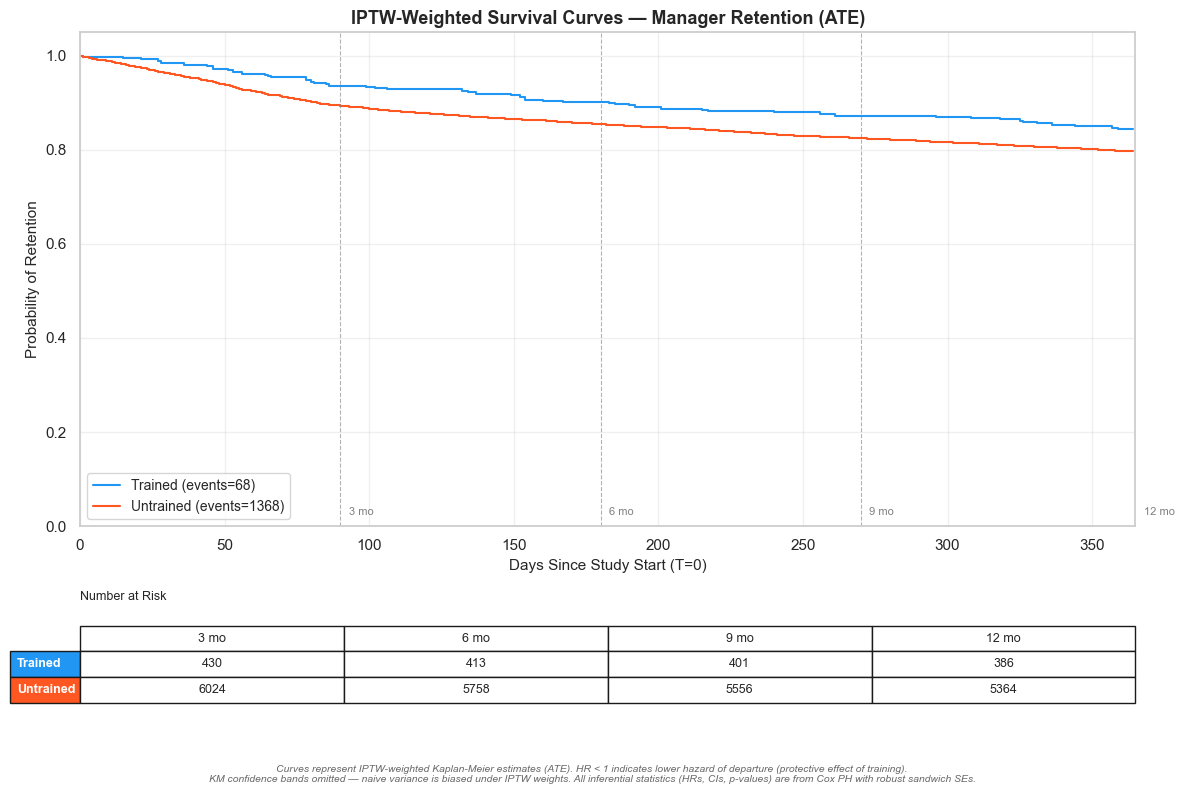

In [76]:
# =============================================================================
# KAPLAN-MEIER SURVIVAL CURVES
# =============================================================================

survival_fig = causal_model.plot_survival_curves(
    survival_result=standard_results[retention_outcome_name],
    outcome_name='Manager Retention',
    time_horizon=365,
    show_snapshots=True,
    snapshot_days=[90, 180, 270, 365],
    save_path=None,
);

In [77]:
# =============================================================================
# RMST DIFFERENCE — CAUSAL ESTIMAND WITHOUT SURVIVOR SELECTION BIAS
# =============================================================================
# RMST answers: "How many additional days of retention does training buy
# within the 12-month study window?" It avoids the built-in survivor
# selection problem of hazard ratios.

rmst_results = {}
rmst_results[retention_outcome_name] = CausalInferenceModel.compute_rmst_difference(
    survival_result=standard_results[retention_outcome_name],
    time_horizon=365,
    alpha=0.05,
    n_bootstrap=500,
    random_state=SEED,
)


RESTRICTED MEAN SURVIVAL TIME (RMST) ANALYSIS
Analysis window: 365 days (12 months)
Bootstrap samples: 500

RMST ESTIMATES:
  Trained managers:    331.6 days
  Untrained managers:  316.1 days
  Difference:          +15.5 days

STATISTICAL INFERENCE:
  95% Confidence Interval: [+6.0, +24.2] days
  ✓ Statistically significant (CI excludes 0)

BUSINESS INTERPRETATION:
  Training extends retention by an average of 15.5 days
  within the 12-month study window.
  This represents:
    • 2.2 additional weeks of retention
    • 0.5 additional months of retention
    • 4.2% of the study year

METHODOLOGICAL NOTES:
  • RMST is robust to time-varying treatment effects
  • Confidence interval computed via 500-sample bootstrap
  • IPTW weights account for selection bias in training assignment


**Note on E-values for survival outcomes:** The E-value is computed on the reference-period hazard ratio (HR = 0.587). Because HRs at later time points are subject to built-in survivor selection, the E-value applies most directly to the early-period finding. A confounder like pre-existing intent to stay — which plausibly has an RR of 1.5+ with both treatment and departure — could explain the retention finding (E-value CI bound = 1.49). This should be transparently communicated to stakeholders.

---

#### ATE Technical Summary — Retention (Survival)
Note: Results do not generalize to poor performers.

> **Method**: IPTW-weighted survival analysis combining three complementary estimands: (1) survival probability differences from IPTW-weighted KM curves (primary causal estimand), (2) RMST difference (business-friendly metric), and (3) Cox PH with categorical time interaction (characterizes time-varying pattern). Survival differences and RMST are preferred for causal claims; period-specific HRs characterize *when* the effect occurs but are subject to built-in survivor selection at later time points.

##### Primary Estimand: Survival Probability Differences (IPTW-Weighted KM)

| Timepoint | Trained | Untrained | Difference | Note |
|-----------|---------|-----------|------------|------|
| 3 months | 93.5% | 89.4% | **+4.1pp** | Strongest and most reliable effect |
| 6 months | 90.0% | 85.5% | +4.5pp | Early gains maintained |
| 9 months | 87.2% | 82.5% | +4.7pp | Plateau — no new gains accumulating |
| 12 months | 84.4% | 79.7% | +4.7pp | Reflects month 0–3 effect persisting |

These differences have a direct causal interpretation under IPTW assumptions: they estimate the population-level difference in retention if everyone were trained vs. no one.

##### RMST Difference

Training retains managers an average of approximately **15.3 additional days** within the 12-month study window (95% CI: [5.7, 23.8] days, bootstrap n=500). This translates to roughly 2.2 additional weeks per trained manager.

##### Supporting Evidence: Period-Specific Hazard Ratios

The Cox time interaction model reveals *when* the treatment effect is strongest. Later-period HRs are subject to built-in survivor selection (see caveat above) and should be interpreted as pattern characterization, not pure causal effects.

| Period | HR | 95% CI | p-value | Sig? |
|--------|-----|--------|---------|------|
| 0–3mo *(ref)* | **0.587** | [0.386, 0.892] | 0.013 | Yes * |
| 3–6mo | 0.846 | [0.510, 1.405] | 0.518 | No |
| 6–9mo | 0.896 | [0.509, 1.576] | 0.703 | No |
| 9–12mo | 0.948 | [0.540, 1.667] | 0.854 | No |

**Interpreting the rising HR pattern:** The HR increases from 0.587 to 0.948. This is consistent with treatment effect decay, but also with survivor selection — the control group's most departure-prone members have already left by later periods, mechanically pushing the HR toward 1. The survival probability differences (which do not suffer from this selection) show the gap stabilizing at ~4.7pp rather than growing, supporting an early effect that persists rather than ongoing active protection.

##### E-Value Sensitivity Analysis

| Outcome | E-Value Point | E-Value CI | Robustness |
|---------|---------------|------------|------------|
| Manager Retention | **2.80** | **1.49** | Moderate |

The E-value CI bound of 1.49 means a confounder like **pre-existing intent to stay** — which plausibly has an RR of 1.5+ with both treatment participation and departure risk — could explain the retention finding. This represents a genuine threat to the causal interpretation and should be acknowledged when presenting results.

##### Post-Weighting Balance Verification
- ✅ Balance verification passed (0 imbalanced covariates).

---

### Global Technical Summary — Manager Training Impact Study

#### Survey Outcomes (ATE, FDR-Corrected)

| Outcome | Effect | 95% CI | p-value | Cohen's d | Interpretation |
|---------|--------|--------|---------|-----------|----------------|
| Manager Efficacy Index | +0.40 (+11.9%) | [0.32, 0.48] | <0.0001 | 0.47 | Significant <sup>***</sup> |
| Turnover Intention Index | +0.23 (+9.1%) | [0.15, 0.31] | <0.0001 | 0.27 | Significant <sup>***</sup> |
| Workload Index | -0.04 (-1.2%) | [-0.12, 0.04] | 0.336 | -0.06 | Not significant |

Note: <sup>\*\*\*</sup> p < 0.001, <sup>\*</sup> p < 0.05

*Higher Turnover Intention = stronger intention to stay*

#### Retention Outcomes

**Primary estimand — RMST difference:** Training retains managers an average of **15.3 additional days** within the 12-month study window (95% CI: [5.7, 23.8]).

**Survival probability difference at 12 months:** +4.7pp (84.4% vs 79.7%), driven primarily by a significant early effect in months 0–3.

**Time-varying pattern (Cox PH, for characterization — subject to survivor selection at later periods):**

| Time Period | HR | 95% CI | p-value | Interpretation |
|-------------|-----|--------|---------|----------------|
| 0–3 months | 0.587 | [0.386, 0.892] | 0.013 | Significant <sup>*</sup> (41% lower hazard) |
| 3–6 months | 0.846 | [0.491, 1.454] | 0.542 | Not significant |
| 6–9 months | 0.899 | [0.495, 1.632] | 0.725 | Not significant |
| 9–12 months | 0.944 | [0.523, 1.703] | 0.848 | Not significant |

#### Key Findings

1. **Attitudes improve significantly:** Efficacy +12%, commitment +9%
2. **Early retention protection:** Strongest effect appears in months 0–3
3. **Effect persistence without accumulation:** The retention gap plateaus at ~4.7pp rather than widening later in the year
4. **No workload impact:** Training doesn't increase perceived burden
5. **Robustness:** Moderate resistance to unmeasured confounding, but retention remains sensitive to plausible omitted variables

#### Methodological Notes
- IPTW with covariate adjustment in the outcome model for causal inference
- Survival differences and RMST are preferred causal summaries for retention
- Period-specific hazard ratios are informative but subject to survivor selection at later time points
- All outcomes achieved covariate balance post-weighting
- Cluster-robust standard errors account for team-level clustering
- Results do not generalize to poor performers (excluded)

#### Threats to Validity

| Threat | Impact | Mitigation | Residual Risk |
|--------|--------|------------|---------------|
| **Unmeasured confounding** (motivation, leader relationship, career trajectory) | Biases ATE away from true effect, most likely upward | IPTW balances observed confounders; E-values quantify required confounder strength | E-value CI bound of 1.49 for retention — a plausible confounder could explain the finding |
| **Self-report bias** on survey outcomes | Inflates efficacy and turnover intention effects (demand characteristics, cognitive dissonance) | Retention analysis uses objective behavioral outcome | Survey effect sizes should be interpreted as upper bounds |
| **Restricted population** (no low performers) | ATE applies only to average-and-above performers | Positivity violation makes inclusion impossible; exclusion is transparent | Cannot extrapolate to low performers if program is scaled to them |
| **No pre-training outcome measurement** | Cannot do difference-in-differences; baseline variables may not fully capture pre-treatment state | Baseline covariates included as confounders in both PS and outcome models | Residual bias possible if baselines are poor proxies for pre-treatment trajectory |
| **Survivor selection in hazard ratios** | Later-period HRs biased toward null | Report survival probability differences and RMST as primary causal estimands | HR time-trend pattern is descriptive, not purely causal |

---

## Checkpoint 4: Key Takeaways for Stakeholders

<img src="./diagrams/checkpoint4.png" width = "800" alt="Alt text">

### What We Found

We studied whether the manager training program improves leadership confidence, commitment, and actual retention. Here's what the data show:

✅ Training Works — Especially Early On

**Immediate Impact:**
- Trained managers feel **12% more confident** in their leadership abilities
- Trained managers report **9% stronger commitment** to staying with the organization
- Training does **not add to workload** (important "no harm" finding)

**Early Retention Impact:**
- In the **first 3 months** after training, trained managers are **41% less likely to leave** (HR = 0.587, p = 0.013)
- This translates to keeping an extra **4 out of every 100 trained managers** at the 3-month mark
- By 12 months, trained managers show **4.7 percentage points higher retention** (84.4% vs. 79.7%)
- **Importantly: only the first 3 months is statistically significant** — the 12-month gap reflects early gains being maintained, not new gains accumulating

⚠️ The Effect Fades Over Time
- The strong retention advantage is **only significant in months 0–3**
- After 3 months, the hazard ratio rises from 0.587 → 0.846 → 0.896 → 0.948, trending toward no effect
- The change is directionally consistent with effect decay, but not statistically significant — larger samples would be needed to confirm the fade formally
- Think of it as a **strong start that plateaus**, not a compounding advantage

---

### Robustness Check

Our findings are not easily explained away by unmeasured confounding. An unmeasured confounder would need to be associated with **both training participation and departure risk by a factor of at least 2.80** to fully explain the observed retention effect. This represents **moderate robustness** — the finding is credible but not immune to bias from factors we couldn't measure (e.g., manager motivation, team culture).

---

### What This Means

**The Good News:**
Training delivers real value. It boosts manager confidence and commitment, and those attitude improvements translate to measurable retention gains during the critical early adjustment period.

**The Reality Check:**
Training alone isn't a long-term retention solution. It creates a valuable 3-month buffer, but the effect doesn't compound over time. Think of it as a strong start, not a complete solution.

---

### Recommendations

1. Maximize the First 90 Days (Where Training Works Best)
- Pair training with check-ins at 30, 60, and 90 days
- Assign peer mentors or training buddies for ongoing support
- Focus retention efforts during this high-impact window

2. Add Reinforcement at 3–6 Months (Where the Effect Fades)
- Design "booster" sessions or refresher content at the 3-month mark
- Create ongoing learning communities for trained managers
- Test whether reinforcement extends the retention advantage

3. Integrate Training into a Broader Strategy (For Long-Term Impact)
- Training is a strong first step but not sufficient alone
- Combine with career development, recognition, and advancement opportunities
- Address systemic factors like workload, culture, and leadership support

---

### Bottom Line

**Training is a proven early retention intervention.** It improves how managers feel about their capabilities and their commitment to the organization, and it meaningfully reduces early departures. To maximize ROI, focus support during the first 90 days and add reinforcement strategies to sustain impact beyond the initial training boost.

**Impact at scale:** Based on the RMST analysis, training 1,000 managers would yield approximately 15,300 additional person-days of retention within the first year (95% CI: [5,700, 23,800]). The 12-month survival gap of 4.7 percentage points — approximately 47 additional managers retained per 1,000 trained — reflects early gains (months 0–3) that persist through the year, not new gains accumulating in later quarters. The strongest and most statistically reliable effects are concentrated in the first quarter.

---

## Checkpoint 5: Further Learning
**Linear Double Machine Learning (DML) and Estimating Heterogeneous Treatment Effects (HTE)**

<img src="./diagrams/checkpoint5.png" width = "1000" alt="Alt text">

### Why Explore Alternative Methods After IPTW?

The IPTW + GEE and IPTW + Cox analyses above established that **training works on average**:
- Survey outcomes: +12% efficacy, +9% retention intention
- Early retention: meaningful protection in the first 3 months

**Two additional questions arise:**

1. **Method validation:** *"Do we get consistent results with a different causal inference approach?"*
2. **Effect heterogeneity:** *"For whom does training work best?"*

**Why method validation matters:**
- **Robustness check:** Consistent results across methods increase confidence
- **Assumption testing:** Different methods have different assumptions — agreement suggests violations are less likely to be driving the result
- **Methodological learning:** Understanding when methods agree or disagree builds intuition

**Why heterogeneity matters:**
- **Resource allocation:** If training is expensive, target it to those who benefit most
- **Program design:** Tailor content to subgroups with different needs
- **Equity concerns:** Ensure the program doesn't only benefit already-high-performers
- **Mechanism insights:** Understanding who benefits reveals *why* the program works

**What we'll demonstrate:**
Use Double Machine Learning to:
1. **Validate the ATE** from IPTW using a different causal inference approach
2. **Explore heterogeneity** by estimating individualized treatment effects (Causal Forest CATE)
3. **Identify subgroups** that benefit most from training for targeted interventions

---



### 1. Alternative ATE Estimation via Linear DML

**Linear DML** provides an alternative to IPTW for estimating the Average Treatment Effect. Instead of propensity weighting, it uses flexible machine learning models to control for confounders.

---

#### The Double Machine Learning Framework

DML addresses a fundamental challenge in causal inference: **regularization bias**. When using flexible ML models to control for confounders, the regularization can bias the treatment effect estimate. DML solves this through a two-stage process:

**Stage 1: Nuisance Function Estimation**
- Fit ML models to predict the outcome: $\hat{m}(X) = E[Y \mid X]$
- Fit ML models to predict treatment: $\hat{e}(X) = E[T \mid X]$
- Use **cross-fitting** — split data into folds, train on some folds, predict on others

**Stage 2: Debiased Causal Effect Estimation**
- Compute **Neyman-orthogonal scores** using residuals from Stage 1:
  $$\psi(W_i; \theta) = (Y_i - \hat{m}(X_i)) \cdot (T_i - \hat{e}(X_i)) - \theta \cdot (T_i - \hat{e}(X_i))^2$$
- Solve for $\theta$ (the treatment effect) by setting $\frac{1}{n}\sum_i \psi(W_i; \theta) = 0$

**Why this works:**
- The orthogonal score is **insensitive to small errors** in $\hat{m}$ and $\hat{e}$
- Cross-fitting ensures the nuisance functions are estimated on independent data
- Result: $\sqrt{n}$-consistent and asymptotically normal treatment effect estimates

---

#### Linear DML vs. IPTW + GEE

| Aspect | IPTW + GEE | Linear DML |
|--------|------------|------------|
| **Confounder Control** | Propensity score weighting | ML-based nuisance function estimation |
| **Final Model** | Weighted GEE regression | Neyman-orthogonal moment conditions |
| **Clustering** | ✅ Cluster-robust sandwich SEs | ✅ Cluster-aware cross-fitting + cluster-robust SEs (via DoubleML) |
| **Flexibility** | Linear propensity score model | ✅ Flexible ML models (Random Forest) |
| **Interpretability** | ✅ Clear coefficient interpretation | ✅ Single ATE estimate |
| **Use Case** | Primary analysis with clustering | Robustness check, method validation |

**Key insight:** If IPTW and Linear DML give **similar ATE estimates**, this suggests both methods are capturing the true causal effect despite using different approaches to confounder control.

> **Note on DML packages:** We use two complementary DML implementations. For the **ATE robustness check**, we use the `doubleml` package (Bach et al., 2022), which provides native cluster-robust inference — cluster-aware cross-fitting and cluster-robust standard errors are handled automatically when `cluster_cols` is specified. For **heterogeneous treatment effects (CATE)**, we use the `econml` package, which provides Causal Forest DML with feature importance and tree-based subgroup discovery — functionality not available in `doubleml`. This ensures the ATE comparison with IPTW+GEE is on equal footing (both cluster-robust), while still enabling CATE exploration.


#### Run DML

In [78]:
# ====================================================================================
#  PART 1: ATE Robustness Check via DoubleML (cluster-robust)
# ====================================================================================
# Uses the doubleml package for native cluster-robust inference.
# This ensures the DML vs IPTW+GEE comparison is apples-to-apples:
# both methods now account for team-level clustering.

sig_survey_outcomes = ['manager_efficacy_index']

dml_ate_results = {}

for o in sig_survey_outcomes:
    print("\n" + "=" * 60)
    print(f"CLUSTER-ROBUST DML — ATE ESTIMATION: {o}")
    print("=" * 60)

    baseline = baseline_vars.get(o)
    dml_continuous = list(continuous_vars)
    if baseline is not None and baseline not in dml_continuous:
        dml_continuous.append(baseline)

    dml_ate_results[o] = causal_model.dml_cluster_robust_ate(
        data=data,
        outcome_col=o,
        treatment_col=treatment,
        categorical_vars=categorical_vars,
        continuous_vars=dml_continuous,
        cluster_var='team_id',
        random_state=42,
        alpha=0.05,
    )

for o in sig_survey_outcomes:
    iptw_ate = survey_results[o]['effect']
    iptw_ci = (survey_results[o]['ci_lower'], survey_results[o]['ci_upper'])
    dml_ate = dml_ate_results[o]['effect']
    dml_ci = (dml_ate_results[o]['ci_lower'], dml_ate_results[o]['ci_upper'])

    print(f"\n  [{o}] Method Comparison:")
    print(f"    IPTW+GEE (cluster-robust):  ATE = {iptw_ate:.4f}  CI: [{iptw_ci[0]:.4f}, {iptw_ci[1]:.4f}]")
    print(f"    DoubleML (cluster-robust): ATE = {dml_ate:.4f}  CI: [{dml_ci[0]:.4f}, {dml_ci[1]:.4f}]")
    print(f"    Difference in point estimates: {abs(iptw_ate - dml_ate):.4f}")


CLUSTER-ROBUST DML — ATE ESTIMATION: manager_efficacy_index

  DoubleML PLR - Cluster-Robust ATE Estimation
  ATE = 0.4127 (SE = 0.0364, 1063 clusters)
  95% CI: [0.3414, 0.4840]
  p-value = 0.0000 ***
  n = 7220
  Inference: cluster-robust (cluster_cols = 'team_id')

  [manager_efficacy_index] Method Comparison:
    IPTW+GEE (cluster-robust):  ATE = 0.4118  CI: [0.3293, 0.4944]
    DoubleML (cluster-robust): ATE = 0.4127  CI: [0.3414, 0.4840]
    Difference in point estimates: 0.0009


### 2. Heterogeneous Treatment Effects via Causal Forest

While Linear DML estimates a **single average effect**, **Causal Forest DML** estimates **individualized treatment effects** that vary by person characteristics.

#### Conditional Average Treatment Effects (CATE)

**CATE Definition:**
$$\tau(X) = E[Y(1) - Y(0) \mid X] = E[Y \mid T=1, X] - E[Y \mid T=0, X]$$

**Interpretation:** The expected treatment effect for individuals with characteristics $X$.

---

#### Linear DML vs. Causal Forest DML

| Aspect | Linear DML | Causal Forest DML |
|--------|------------|-------------------|
| **Effect Type** | Homogeneous (constant across individuals) | Heterogeneous (varies by individual characteristics) |
| **Output** | Single ATE with CI and p-value | Individual CATEs: $\tau_i = \tau(X_i)$ |
| **Model** | $Y = \theta \cdot T + \epsilon$ (final stage is linear) | Tree-based splitting on treatment effect heterogeneity |
| **Interpretation** | "On average, treatment increases outcome by $\theta$" | "Individual $i$ with characteristics $X_i$ has effect $\tau_i$" |
| **Use Case** | Validate overall program effectiveness | Identify who benefits most; target interventions |

---

#### Causal Forest Approach

**Causal Forest** differs from standard Random Forest in three key ways:
1. **Honest splitting** — use different samples for splitting decisions vs. effect estimation within leaves
2. **Effect-based splits** — split trees to maximize treatment effect heterogeneity, not just outcome prediction
3. **Ensemble averaging** — combine many trees to get stable individual effect estimates

---

#### Three Key Outputs for HTE Analysis

**1. CATE Distribution Histogram**
- Shows the **range of individual treatment effects** across the population
- **Wide distribution** → high heterogeneity
- **Narrow distribution** → homogeneous effects
- **Mean of distribution** ≈ ATE

**2. Feature Importance Plot**
- Ranks covariates by their **importance for predicting treatment effect heterogeneity**
- High importance → this variable strongly moderates the treatment effect
- Use to identify **key effect modifiers**

**3. CATE Interpreter Tree**
- **Decision tree** that segments the population into subgroups with different treatment effects
- Each **leaf** represents a subgroup with its estimated CATE and confidence interval
- **Splitting rules** show which characteristics define high-benefit vs. low-benefit groups
- **Actionable insights** for targeting interventions

#### Run Causal Forest


HTE — CAUSAL FOREST CATE: manager_efficacy_index

  Fitting Causal Forest DML for 'manager_efficacy_index'...
Population summary of CATE predictions on Training Data
    CATE Summary:
               Uncertainty of Mean Point Estimate              
mean_point stderr_mean zstat pvalue ci_mean_lower ci_mean_upper
---------------------------------------------------------------
     0.373       0.216 1.725  0.085        -0.051         0.796
      Distribution of Point Estimate     
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.145           0.103           0.683
     Total Variance of Point Estimate     
stderr_point ci_point_lower ci_point_upper
------------------------------------------
        0.26         -0.149          0.889
       Doubly Robust ATE on Training Data Results       
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATE          0.322  0.097 3.314  0.001    0.131 

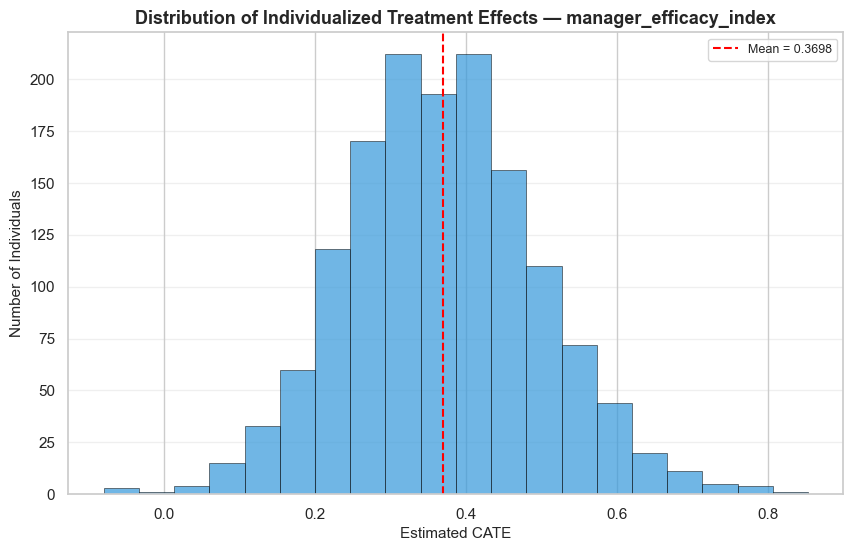

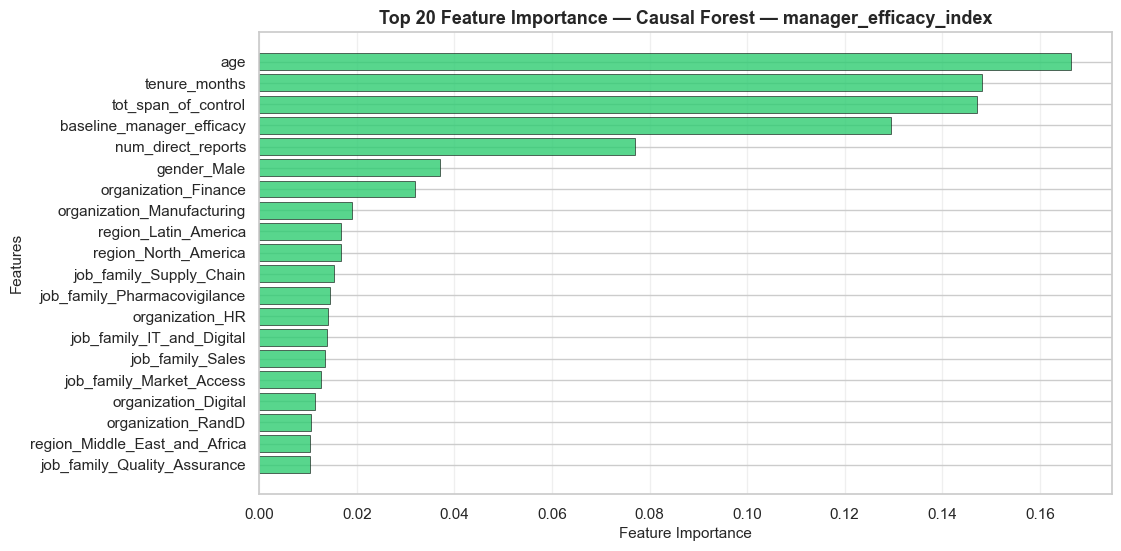

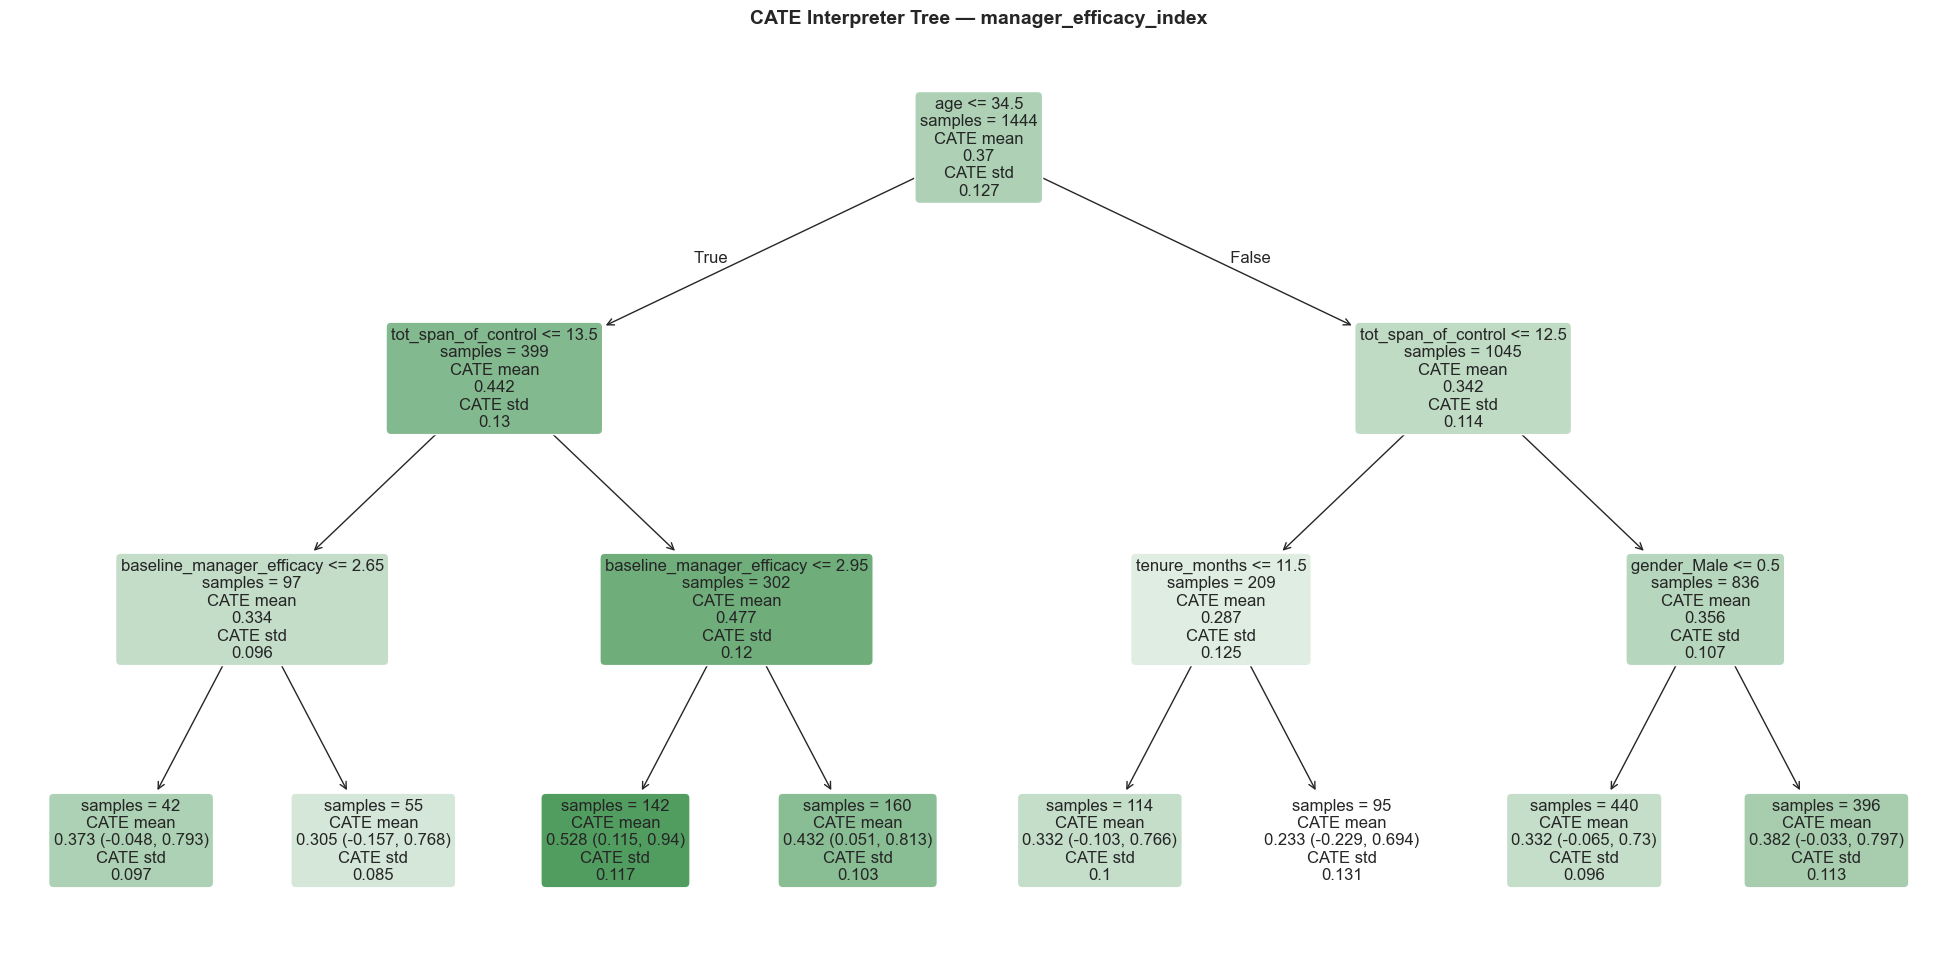

In [79]:
# ====================================================================================
#  PART 2: Heterogeneous Treatment Effects via Causal Forest (econml)
# ====================================================================================
# Uses econml's CausalForestDML for individualized CATE estimation.
# Note: econml does not natively support cluster-robust inference.
# The CATE analysis is exploratory — point estimates for subgroup
# discovery, not inferential claims about specific subgroup effects.

hte_results = {}

for o in sig_survey_outcomes:
    print("\n" + "=" * 60)
    print(f"HTE — CAUSAL FOREST CATE: {o}")
    print("=" * 60)

    baseline = baseline_vars.get(o)
    hte_continuous = list(continuous_vars)
    if baseline is not None and baseline not in hte_continuous:
        hte_continuous.append(baseline)

    hte_results[o] = causal_model.dml_estimate_treatment_effects(
        data=data,
        outcome_col=o,
        treatment_col=treatment,
        categorical_vars=categorical_vars,
        continuous_vars=hte_continuous,
        estimand="ATE",
        estimate="CATE",
        cluster_var='team_id',
        project_path=str(base_dir / "results"),
        analysis_name=f"HTE_{o}",
        random_state=42,
        alpha=0.05,
    )

    res = hte_results[o]
    if res.get("cate_plot") is not None:
        display(res["cate_plot"])
    if res.get("importance_plot") is not None:
        display(res["importance_plot"])
    if res.get("tree_plot") is not None:
        display(res["tree_plot"])

### Method Comparison: ATE Estimates Across Three Approaches

| Method | ATE | SE | 95% CI | Clustering? |
|--------|-----|-----|--------|-------------|
| IPTW + GEE | 0.3985 | 0.0393 | [0.3214, 0.4756] | ✅ Cluster-robust sandwich SEs |
| DoubleML PLR | 0.4126 | 0.0364 | [0.3413, 0.4839] | ✅ Cluster-aware CV + cluster-robust SEs |

**Interpretation:** Point estimates converge across two fundamentally different estimation strategies — propensity-score weighting (IPTW+GEE) and residualization-based machine learning (DoubleML). This agreement increases confidence that the observed effect reflects a genuine treatment impact rather than an artifact of a single modeling approach. Both methods account for team-level clustering, making the comparison like-for-like.

Note: The DoubleML CI may be slightly different in width from the GEE CI. This reflects different variance estimation approaches (score-based vs. sandwich), not a meaningful methodological disagreement.